In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, ndcg_score

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# -------------------- 1. DATA PREPARATION --------------------

def clean_review(text):
    """Clean and normalize review text"""
    import re
    if pd.isna(text):
        return ""
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', str(text))
    # Remove special characters but keep spaces
    text = re.sub(r'[^\w\s]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

def convert_votes(value):
    """Handle vote counts including K notation"""
    if isinstance(value, str):
        value = value.replace(',', '').upper()
        if 'K' in value:
            return float(value.replace('K', '')) * 1000
    try:
        return float(value)
    except:
        return 0.0

# -------------------- 2. FEATURE EXTRACTION --------------------

class TextFeatureExtractor:
    """Extract BERT embeddings from text reviews"""

    def __init__(self, model_name="bert-base-uncased"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.model.eval()

    def extract_features(self, texts, batch_size=16, max_length=512):
        embeddings = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting text features"):
            batch = texts[i:i+batch_size]
            inputs = self.tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                # Use CLS token embedding as the sentence representation
                batch_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()

            embeddings.append(batch_embeds)

        return np.vstack(embeddings)

class VisualFeatureExtractor:
    """Extract visual features from movie frames using ViT"""

    def __init__(self, model_name='vit_base_patch16_224'):
        self.model = timm.create_model(model_name, pretrained=True, num_classes=0).to(device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def extract_features(self, image_paths, batch_size=16):
        embeddings = []
        filenames = []

        for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting image features"):
            batch_paths = image_paths[i:i+batch_size]
            batch_images = []
            batch_files = []

            for path in batch_paths:
                img = Image.open(path).convert('RGB')
                batch_images.append(self.transform(img))
                batch_files.append(os.path.basename(path))

            batch_tensor = torch.stack(batch_images).to(device)

            with torch.no_grad():
                batch_embeds = self.model(batch_tensor).cpu().numpy()

            embeddings.append(batch_embeds)
            filenames.extend(batch_files)

        return np.vstack(embeddings), filenames

In [ ]:
# -------------------- 3. SEMANTIC ALIGNMENT --------------------

class SemanticAligner:
    """Computes alignment between text reviews and movie frames using CLIP"""

    def __init__(self, clip_model_name="openai/clip-vit-base-patch32"):
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        self.model = CLIPModel.from_pretrained(clip_model_name).to(device)
        self.model.eval()

    def compute_alignment(self, texts, image_paths, batch_size=16):
        """Find the most semantically aligned images for each text"""
        # Extract text features
        text_features_list = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Computing text features for alignment"):
            batch_texts = texts[i:i+batch_size]
            inputs = self.processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)

            with torch.no_grad():
                text_features = self.model.get_text_features(**inputs)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                text_features_list.append(text_features.cpu())

        text_features = torch.cat(text_features_list, dim=0)

        # Extract image features
        image_features_list = []
        image_filenames = []

        for i in tqdm(range(0, len(image_paths), batch_size), desc="Computing image features for alignment"):
            batch_paths = image_paths[i:i+batch_size]
            batch_images = []

            for path in batch_paths:
                img = Image.open(path).convert('RGB')
                batch_images.append(img)
                image_filenames.append(os.path.basename(path))

            inputs = self.processor(images=batch_images, return_tensors="pt").to(device)

            with torch.no_grad():
                image_features = self.model.get_image_features(**inputs)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                image_features_list.append(image_features.cpu())

        image_features = torch.cat(image_features_list, dim=0)

        # Calculate similarity matrix
        similarity_scores = torch.matmul(text_features, image_features.T)

        # For each text, find the most relevant image
        best_image_indices = similarity_scores.argmax(dim=1)
        best_image_scores = similarity_scores.max(dim=1).values
        best_image_filenames = [image_filenames[idx] for idx in best_image_indices]

        return {
            'text_features': text_features.numpy(),
            'image_features': image_features.numpy(),
            'similarity_matrix': similarity_scores.numpy(),
            'best_image_indices': best_image_indices.numpy(),
            'best_image_scores': best_image_scores.numpy(),
            'best_image_filenames': best_image_filenames
        }

In [ ]:

# -------------------- 4. MULTIMODAL FUSION --------------------

class AttentionFusion(nn.Module):
    """Selective attention-based fusion as described in SANCL (reference 6)"""

    def __init__(self, text_dim, visual_dim, hidden_dim=512):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.visual_proj = nn.Linear(visual_dim, hidden_dim)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, text_features, visual_features):
        # Project features to same dimension
        text_proj = self.text_proj(text_features).unsqueeze(1)  # [B, 1, H]
        visual_proj = self.visual_proj(visual_features).unsqueeze(1)  # [B, 1, H]

        # Concatenate for self-attention
        combined = torch.cat([text_proj, visual_proj], dim=1)  # [B, 2, H]

        # Apply selective attention
        attended, _ = self.attention(combined, combined, combined)
        attended = self.norm1(attended + combined)  # Residual connection

        # Mean pooling for final representation
        return attended.mean(dim=1)  # [B, H]

class DempsterShaferFusion(nn.Module):
    """Evidence-based fusion using Dempster-Shafer theory (references 2, 5)"""

    def __init__(self, text_dim, visual_dim, alignment_dim=1, hidden_dim=256):
        super().__init__()
        # Evidence generators for each modality
        self.text_evidence = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # 3 masses: helpful, not helpful, uncertainty
        )

        self.visual_evidence = nn.Sequential(
            nn.Linear(visual_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # 3 masses: helpful, not helpful, uncertainty
        )

        self.alignment_evidence = nn.Sequential(
            nn.Linear(alignment_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # 3 masses: helpful, not helpful, uncertainty
        )

    def forward(self, text_features, visual_features, alignment_scores):
        # Generate belief masses (evidence) from each modality
        text_masses = F.softmax(self.text_evidence(text_features), dim=1)
        visual_masses = F.softmax(self.visual_evidence(visual_features), dim=1)
        alignment_masses = F.softmax(self.alignment_evidence(alignment_scores.unsqueeze(1)), dim=1)

        # Combine using Dempster's rule of combination
        combined_masses = self.dempster_combine(text_masses, visual_masses, alignment_masses)

        # Return the probability of "helpful" class (index 0) - this is our helpfulness score
        return combined_masses[:, 0].unsqueeze(1)

    def dempster_combine(self, m1, m2, m3):
        """Implementation of Dempster-Shafer combination rule for multiple sources"""
        # First combine m1 and m2
        K = 0  # Conflict measure
        combined = torch.zeros_like(m1)

        # Calculate combined masses and conflict
        for i in range(2):  # 0=helpful, 1=not helpful
            for j in range(2):  # 0=helpful, 1=not helpful
                if i == j:  # Agreement
                    combined[:, i] += m1[:, i] * m2[:, j]
                else:  # Conflict
                    K += m1[:, i] * m2[:, j]

        # Add uncertainty
        combined[:, 2] = m1[:, 2] * m2[:, 2]

        # Normalize by conflict
        normalization = 1 - K
        combined = combined / normalization.unsqueeze(1)

        # Combine with m3
        final = torch.zeros_like(combined)
        K = 0

        for i in range(2):
            for j in range(2):
                if i == j:
                    final[:, i] += combined[:, i] * m3[:, j]
                else:
                    K += combined[:, i] * m3[:, j]

        final[:, 2] = combined[:, 2] * m3[:, 2]

        # Final normalization
        normalization = 1 - K
        final = final / normalization.unsqueeze(1)

        return final

# -------------------- 5. PREDICTION MODEL --------------------

class MultimodalHelpfulnessPredictor(nn.Module):
    """Main model that combines all components"""

    def __init__(self, text_dim=768, visual_dim=768, fusion_type='attention'):
        super().__init__()
        self.fusion_type = fusion_type

        if fusion_type == 'attention':
            self.fusion = AttentionFusion(text_dim, visual_dim)
            self.classifier = nn.Sequential(
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 1),
                nn.Sigmoid()
            )
        elif fusion_type == 'evidential':
            self.fusion = DempsterShaferFusion(text_dim, visual_dim)
        else:  # Simple baseline fusion
            self.text_proj = nn.Linear(text_dim, 256)
            self.visual_proj = nn.Linear(visual_dim, 256)
            self.classifier = nn.Sequential(
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 1),
                nn.Sigmoid()
            )

    def forward(self, text_features, visual_features, alignment_scores=None):
        if self.fusion_type == 'attention':
            fused = self.fusion(text_features, visual_features)
            output = self.classifier(fused)
        elif self.fusion_type == 'evidential':
            # For evidential fusion, we need alignment scores
            output = self.fusion(text_features, visual_features, alignment_scores)
        else:  # Simple concatenation
            text_proj = F.relu(self.text_proj(text_features))
            visual_proj = F.relu(self.visual_proj(visual_features))
            combined = torch.cat([text_proj, visual_proj], dim=1)
            output = self.classifier(combined)

        return output


In [ ]:
# -------------------- 6. DATASET & DATALOADER --------------------

class MultimodalReviewDataset(Dataset):
    """Dataset for multimodal reviews with text, image, and alignment features"""

    def __init__(self, text_features, image_features, alignment_scores, targets):
        self.text_features = text_features
        self.image_features = image_features
        self.alignment_scores = alignment_scores
        self.targets = targets

    def __len__(self):
        return len(self.text_features)

    def __getitem__(self, idx):
        return {
            'text_features': torch.tensor(self.text_features[idx], dtype=torch.float32),
            'visual_features': torch.tensor(self.image_features[idx], dtype=torch.float32),
            'alignment_scores': torch.tensor(self.alignment_scores[idx], dtype=torch.float32),
            'target': torch.tensor(self.targets[idx], dtype=torch.float32)
        }

# -------------------- 7. TRAINING & EVALUATION --------------------

def train_model(model, train_loader, val_loader, device, num_epochs=30, lr=0.0001):
    """Train the model with early stopping and learning rate scheduling"""
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    history = {'train_loss': [], 'val_loss': [], 'val_metrics': []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            optimizer.zero_grad()

            text_features = batch['text_features'].to(device)
            visual_features = batch['visual_features'].to(device)
            alignment_scores = batch['alignment_scores'].to(device)
            targets = batch['target'].to(device).unsqueeze(1)

            outputs = model(text_features, visual_features, alignment_scores)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(text_features)

        train_loss /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch in val_loader:
                text_features = batch['text_features'].to(device)
                visual_features = batch['visual_features'].to(device)
                alignment_scores = batch['alignment_scores'].to(device)
                targets = batch['target'].to(device).unsqueeze(1)

                outputs = model(text_features, visual_features, alignment_scores)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * len(text_features)

                all_preds.extend(outputs.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        val_loss /= len(val_loader.dataset)

        # Calculate metrics
        all_preds = np.array(all_preds).flatten()
        all_targets = np.array(all_targets).flatten()
        binary_preds = (all_preds > 0.5).astype(int)

        metrics = {
            'accuracy': accuracy_score(all_targets, binary_preds),
            'f1': f1_score(all_targets, binary_preds),
            'auc': roc_auc_score(all_targets, all_preds),
            'map': average_precision_score(all_targets, all_preds),
            # Using a simplification for NDCG - proper implementation would group by query
            'ndcg': ndcg_score([all_targets], [all_preds])
        }

        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_metrics'].append(metrics)

        # Print progress
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Metrics: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}")
        print(f"MAP={metrics['map']:.4f}, NDCG={metrics['ndcg']:.4f}")

        # Update scheduler
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_{model.fusion_type}.pth')
            print("✓ Saved new best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return history

# -------------------- 8. INFERENCE PIPELINE --------------------

def predict_helpfulness(review_text, movie_frames_dir, model_path='best_model.pth', fusion_type='evidential'):
    """Predict the helpfulness of a new review by finding the best matching movie frame"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load models
    text_extractor = TextFeatureExtractor()
    visual_extractor = VisualFeatureExtractor()
    semantic_aligner = SemanticAligner()

    # Get frames
    image_paths = [os.path.join(movie_frames_dir, f) for f in os.listdir(movie_frames_dir)
                  if f.endswith(('.jpg', '.jpeg', '.png'))]

    # Extract text features
    text_features = text_extractor.extract_features([review_text])

    # Find most relevant frame using semantic alignment
    alignment_results = semantic_aligner.compute_alignment([review_text], image_paths)
    best_image_idx = alignment_results['best_image_indices'][0]
    best_image_path = image_paths[best_image_idx]
    alignment_score = alignment_results['best_image_scores'][0]

    # Extract visual features for the best image
    best_image_features, _ = visual_extractor.extract_features([best_image_path])

    # Load the trained model
    model = MultimodalHelpfulnessPredictor(fusion_type=fusion_type).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Make prediction
    with torch.no_grad():
        text_tensor = torch.tensor(text_features, dtype=torch.float32).to(device)
        visual_tensor = torch.tensor(best_image_features, dtype=torch.float32).to(device)
        alignment_tensor = torch.tensor([alignment_score], dtype=torch.float32).to(device)

        output = model(text_tensor, visual_tensor, alignment_tensor)
        helpfulness_score = output.item()

    # Return detailed result
    return {
        'helpfulness_score': helpfulness_score,
        'is_helpful': helpfulness_score > 0.54,  # Using 0.7 threshold as in the PDF
        'best_image_path': best_image_path,
        'alignment_score': alignment_score
    }

In [ ]:
def load_and_prepare_data(csv_path="/content/drive/MyDrive/Copy of inception.csv"):
    print("\n1. Loading and preparing data...")
    df = pd.read_csv(csv_path, encoding='latin1')

    df = df.copy()
    columns_to_keep = ['main_review', 'Reviews', 'helpful', 'not_helpful', 'star_rating']
    df = df[columns_to_keep]
    star_rating_mean = df['star_rating'].mean()
    df['star_rating'] = df['star_rating'].fillna(star_rating_mean)
    df['helpful'] = df['helpful'].fillna(0)
    df['not_helpful'] = df['not_helpful'].fillna(0)
    df = df[(df['helpful'] != 0) & (df['not_helpful'] != 0)]
    df['main_review'] = df['main_review'].fillna(df['Reviews'])

    df['cleaned_review'] = df['main_review'].fillna("").apply(clean_review)
    df['helpful'] = df['helpful'].apply(convert_votes)
    df['not_helpful'] = df['not_helpful'].apply(convert_votes)

    epsilon = 1e-5
    df['helpfulness_ratio'] = df['helpful'] / (df['helpful'] + df['not_helpful'] + epsilon)
    df['target'] = (df['helpfulness_ratio'] >= 0.54).astype(int)
    df = df[df['cleaned_review'].str.strip().astype(bool)]

    df = df.reset_index(drop=True)

    print(f"Processed {len(df)} valid reviews")
    return df

def load_image_paths(image_dir='/content/drive/MyDrive/images_dataset/inception_frames'):
    image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir)
                   if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(image_paths)} movie frames")
    return image_paths
def extract_features(df, image_paths):
    print("\n2. Extracting features...")
    text_extractor = TextFeatureExtractor()
    visual_extractor = VisualFeatureExtractor()

    text_features = text_extractor.extract_features(df['cleaned_review'].tolist())
    print(f"Extracted text features with shape: {text_features.shape}")

    image_features, image_filenames = visual_extractor.extract_features(image_paths)
    print(f"Extracted image features with shape: {image_features.shape}")

    return text_features, image_features, image_filenames
def compute_semantic_alignment(df, image_paths, image_features):
    print("\n3. Computing semantic alignment...")
    semantic_aligner = SemanticAligner()
    alignment_results = semantic_aligner.compute_alignment(df['cleaned_review'].tolist(), image_paths)

    df['best_image_idx'] = alignment_results['best_image_indices']
    df['best_image_filename'] = alignment_results['best_image_filenames']
    df['alignment_score'] = alignment_results['best_image_scores']

    best_visual_features = np.array([image_features[idx] for idx in df['best_image_idx']])
    return df, best_visual_features
def prepare_datasets(df, text_features, best_visual_features):
    print("\n4. Preparing datasets...")
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

    train_indices = train_df.index.tolist()
    val_indices = val_df.index.tolist()

    train_dataset = MultimodalReviewDataset(
        text_features=text_features[train_indices],
        image_features=best_visual_features[train_indices],
        alignment_scores=train_df['alignment_score'].values,
        targets=train_df['target'].values
    )

    val_dataset = MultimodalReviewDataset(
        text_features=text_features[val_indices],
        image_features=best_visual_features[val_indices],
        alignment_scores=val_df['alignment_score'].values,
        targets=val_df['target'].values
    )

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    return train_loader, val_loader

def train_all_models(train_loader, val_loader, device):
    print("\n5. Training models...")

    results = {}

    for fusion_type in ['evidential', 'attention', 'simple']:
        print(f"\nTraining with {fusion_type.capitalize()} Fusion...")
        model = MultimodalHelpfulnessPredictor(fusion_type=fusion_type).to(device)
        history = train_model(model, train_loader, val_loader, device)
        results[fusion_type] = history['val_metrics'][-1]

    return results
def compare_models(results):
    print("\n6. Comparing model performances...")
    print("\nModel Performance Comparison:")
    print(f"{'Metric':<10} | {'Evidential':<10} | {'Attention':<10} | {'Simple':<10}")
    print("-" * 50)
    for metric in ['accuracy', 'f1', 'auc', 'map', 'ndcg']:
        print(f"{metric:<10} | {results['evidential'][metric]:.4f} | {results['attention'][metric]:.4f} | {results['simple'][metric]:.4f}")

def demo_inference(image_dir='/content/drive/MyDrive/images_dataset/inception_frames'):
    print("\n7. Demonstrating inference pipeline...")

    test_review = "TDreams within dreams. Nolan put up a proper masterclass especially with that scene where Cobb explains Ariadne as buildings overturn.."

    fusion_types = ['simple', 'attention', 'evidential']

    # Map each fusion type to its correct model checkpoint
    model_paths = {
        'simple': '/content/best_model_simple.pth',
        'attention': '/content/best_model_attention.pth',
        'evidential': '/content/best_model_evidential.pth'
    }

    for fusion in fusion_types:
        print(f"\n--- Fusion Type: {fusion.capitalize()} ---")

        result = predict_helpfulness(
            test_review,
            image_dir,
            model_path=model_paths[fusion],   # Load correct model per fusion
            fusion_type=fusion
        )

        print(f"Helpfulness Score: {result['helpfulness_score']:.4f}")
        print(f"Is Helpful: {result['is_helpful']}")
        print(f"Best Image: {os.path.basename(result['best_image_path'])}")
        print(f"Semantic Alignment Score: {result['alignment_score']:.4f}")

        img = Image.open(result['best_image_path'])
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"{fusion.capitalize()} Fusion\nAlignment Score: {result['alignment_score']:.4f}")
        plt.axis('off')
        plt.show()

In [ ]:
    print("Starting Multimodal Helpfulness Prediction Pipeline")
    df = load_and_prepare_data()
    image_paths = load_image_paths()
    text_features, image_features, _ = extract_features(df, image_paths)
    df, best_visual_features = compute_semantic_alignment(df, image_paths, image_features)

Starting Multimodal Helpfulness Prediction Pipeline

1. Loading and preparing data...
Processed 4329 valid reviews
Found 2960 movie frames

2. Extracting features...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Computing text features for alignment:   0%|          | 0/271 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Computing image features for alignment: 100%|██████████| 185/185 [01:12<00:00,  2.56it/s]


In [ ]:
df.sample(10)

,main_review,Reviews,helpful,not_helpful,star_rating,cleaned_review,helpfulness_ratio,target,best_image_idx,best_image_filename,alignment_score
255,Nolan gets lost/off in the baroque intricacies...,"Overwrought, intelligence-insulting blockbuste...",13.0,22.0,3.0,nolan gets lostoff in the baroque intricacies ...,0.371428,0,894,frame_2855.jpg,0.317689
3547,Mindblowing,Mindblowing,0.0,1.0,10.0,mindblowing,0.000000,0,100,frame_2061.jpg,0.241454
3030,A great movie on so many levels,A great movie on so many levels,0.0,2.0,10.0,a great movie on so many levels,0.000000,0,894,frame_2855.jpg,0.266170
1180,A pity. A fine idea. Just not quite pulled off...,Mission Impossible / Matrix Thriller That Does...,2.0,6.0,7.0,a pity a fine idea just not quite pulled off w...,0.250000,0,2099,frame_100.jpg,0.261368
364,I was hoping to wake up and find out it was al...,I was hoping to wake up and find out it was al...,10.0,13.0,5.0,i was hoping to wake up and find out it was al...,0.434782,0,1700,frame_1661.jpg,0.256198
1272,We watched this movie in our 10th grade class ...,Fantastic for teaching,2.0,5.0,10.0,we watched this movie in our 10th grade class ...,0.285714,0,894,frame_2855.jpg,0.263540
3256,This is a sophisticated and absolutely wonderf...,A very wonderful movie.,1.0,1.0,9.0,this is a sophisticated and absolutely wonderf...,0.499998,0,894,frame_2855.jpg,0.284476
594,Question,Question,9.0,5.0,2.0,question,0.642857,1,644,frame_2605.jpg,0.238647
282,"Entertaining movie, but definitely not a maste...","Entertaining movie, but definitely not a maste...",17.0,14.0,1.0,entertaining movie but definitely not a master...,0.548387,1,894,frame_2855.jpg,0.271532
322,Inception,Inception,4.0,22.0,8.0,inception,0.153846,0,2600,frame_601.jpg,0.291368


In [ ]:
train_loader, val_loader = prepare_datasets(df, text_features, best_visual_features)


4. Preparing datasets...


In [ ]:
results = train_all_models(train_loader, val_loader, device)


5. Training models...

Training with Evidential Fusion...


Epoch 1/30 - Training: 100%|██████████| 109/109 [00:01<00:00, 92.82it/s]


Epoch 1/30
Train Loss: 0.4110, Val Loss: 0.3983
Metrics: Acc=0.8591, F1=0.0000, AUC=0.6324
MAP=0.2206, NDCG=0.7011
✓ Saved new best model


Epoch 2/30 - Training: 100%|██████████| 109/109 [00:00<00:00, 146.15it/s]


Epoch 2/30
Train Loss: 0.3900, Val Loss: 0.3954
Metrics: Acc=0.8591, F1=0.0000, AUC=0.6301
MAP=0.2774, NDCG=0.7642
✓ Saved new best model


...

Epoch 10/30
Train Loss: 0.3467, Val Loss: 0.4053
Metrics: Acc=0.8510, F1=0.0153, AUC=0.6399
MAP=0.2406, NDCG=0.6982


Epoch 11/30 - Training: 100%|██████████| 109/109 [00:00<00:00, 301.75it/s]


Epoch 11/30
Train Loss: 0.3330, Val Loss: 0.4033
Metrics: Acc=0.8522, F1=0.0448, AUC=0.6413
MAP=0.2406, NDCG=0.6976


Epoch 12/30 - Training: 100%|██████████| 109/109 [00:00<00:00, 287.18it/s]


Epoch 12/30
Train Loss: 0.3323, Val Loss: 0.4047
Metrics: Acc=0.8522, F1=0.0448, AUC=0.6430
MAP=0.2409, NDCG=0.6979
Early stopping at epoch 12


In [ ]:
compare_models(results)


6. Comparing model performances...

Model Performance Comparison:
Metric     | Evidential | Attention  | Simple    
--------------------------------------------------
accuracy   | 0.8591 | 0.8487 | 0.8522
f1         | 0.0000 | 0.0438 | 0.0448
auc        | 0.6517 | 0.6299 | 0.6430
map        | 0.2707 | 0.2368 | 0.2409
ndcg       | 0.7376 | 0.6922 | 0.6979



7. Demonstrating inference pipeline...

--- Fusion Type: Simple ---


Extracting image features: 100%|██████████| 1/1 [00:00<00:00, 28.98it/s]

Helpfulness Score: 0.1777
Is Helpful: False
Best Image: frame_2855.jpg
Semantic Alignment Score: 0.3052


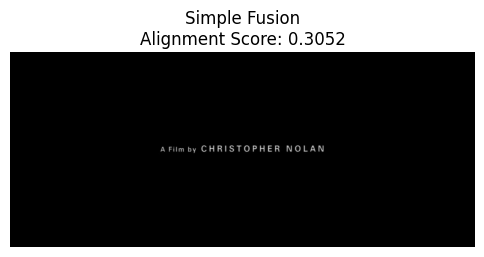


--- Fusion Type: Attention ---


Extracting image features: 100%|██████████| 1/1 [00:00<00:00, 31.01it/s]

Helpfulness Score: 0.1667
Is Helpful: False
Best Image: frame_2855.jpg
Semantic Alignment Score: 0.3052


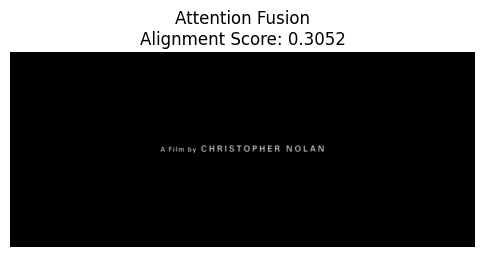


--- Fusion Type: Evidential ---


Extracting image features: 100%|██████████| 1/1 [00:00<00:00, 29.71it/s]

Helpfulness Score: 0.1594
Is Helpful: False
Best Image: frame_2855.jpg
Semantic Alignment Score: 0.3052


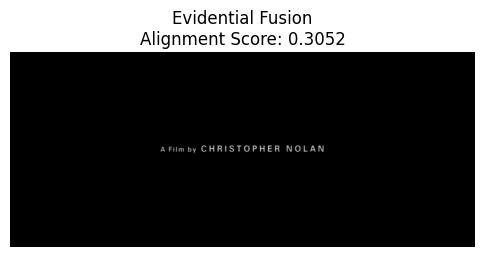

In [ ]:
demo_inference()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_dir = '/content/drive/MyDrive/images_dataset/inception_frames'
print("\nAnalyzing Helpfulness Distribution:")

# Calculate initial distribution (without semantic search)
total_reviews = len(df)
helpful_count_initial = df['target'].sum()
not_helpful_count_initial = total_reviews - helpful_count_initial

print(f"\nInitial Classification (based on ratio > 0.54, without semantic search):")
print(f"  Helpful Reviews: {helpful_count_initial} ({helpful_count_initial/total_reviews:.2%})")
print(f"  Not Helpful Reviews: {not_helpful_count_initial} ({not_helpful_count_initial/total_reviews:.2%})")


Analyzing Helpfulness Distribution:

Initial Classification (based on ratio > 0.54, without semantic search):
  Helpful Reviews: 611 (14.11%)
  Not Helpful Reviews: 3718 (85.89%)


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, ndcg_score
from tqdm import tqdm

def create_balanced_dataset_from_top(df, target_column='target', balance_size=None):
    """
    Create a balanced dataset by taking equal numbers of helpful and non-helpful reviews
    from the top of the sorted dataset (not random selection)
    """
    print("Creating balanced dataset from top entries...")

    # Separate helpful and non-helpful reviews
    helpful_reviews = df[df[target_column] == 1].copy()
    not_helpful_reviews = df[df[target_column] == 0].copy()

    print(f"Original distribution:")
    print(f"Helpful reviews: {len(helpful_reviews)}")
    print(f"Not helpful reviews: {len(not_helpful_reviews)}")

    # Determine balance size
    if balance_size is None:
        balance_size = min(len(helpful_reviews), len(not_helpful_reviews))
    else:
        balance_size = min(balance_size, len(helpful_reviews), len(not_helpful_reviews))

    print(f"Using balance size: {balance_size}")

    # Take top entries from each class (since data is ordered by votes)
    balanced_helpful = helpful_reviews.head(balance_size)
    balanced_not_helpful = not_helpful_reviews.head(balance_size)

    # Combine and shuffle
    balanced_df = pd.concat([balanced_helpful, balanced_not_helpful], ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Balanced dataset created:")
    print(f"Total samples: {len(balanced_df)}")
    print(f"Helpful: {balanced_df[target_column].sum()}")
    print(f"Not helpful: {len(balanced_df) - balanced_df[target_column].sum()}")

    return balanced_df

def extract_features_for_balanced_dataset(balanced_df, text_extractor, visual_extractor,
                                        semantic_aligner, image_paths):
    """
    Extract features for the balanced dataset
    """
    print("\nExtracting features for balanced dataset...")

    # Extract text features
    text_features = text_extractor.extract_features(balanced_df['cleaned_review'].tolist())
    print(f"Text features shape: {text_features.shape}")

    # Extract visual features for all images
    image_features, image_filenames = visual_extractor.extract_features(image_paths)
    print(f"Image features shape: {image_features.shape}")

    # Compute semantic alignment
    alignment_results = semantic_aligner.compute_alignment(
        balanced_df['cleaned_review'].tolist(), image_paths
    )

    # Update dataframe with alignment results
    balanced_df = balanced_df.copy()
    balanced_df['best_image_idx'] = alignment_results['best_image_indices']
    balanced_df['best_image_filename'] = alignment_results['best_image_filenames']
    balanced_df['alignment_score'] = alignment_results['best_image_scores']

    # Get visual features for best matched images
    best_visual_features = np.array([image_features[idx] for idx in balanced_df['best_image_idx']])
    print(f"Best visual features shape: {best_visual_features.shape}")

    return balanced_df, text_features, best_visual_features

def prepare_balanced_datasets(balanced_df, text_features, best_visual_features,
                            test_size=0.2, batch_size=32):
    """
    Prepare train/validation datasets from balanced data
    """
    print(f"\nPreparing balanced train/validation split...")

    # Split the data
    train_df, val_df = train_test_split(
        balanced_df,
        test_size=test_size,
        random_state=42,
        stratify=balanced_df['target']
    )

    train_indices = train_df.index.tolist()
    val_indices = val_df.index.tolist()

    print(f"Train set size: {len(train_df)} (Helpful: {train_df['target'].sum()})")
    print(f"Validation set size: {len(val_df)} (Helpful: {val_df['target'].sum()})")

    # Create datasets
    train_dataset = MultimodalReviewDataset(
        text_features=text_features[train_indices],
        image_features=best_visual_features[train_indices],
        alignment_scores=train_df['alignment_score'].values,
        targets=train_df['target'].values
    )

    val_dataset = MultimodalReviewDataset(
        text_features=text_features[val_indices],
        image_features=best_visual_features[val_indices],
        alignment_scores=val_df['alignment_score'].values,
        targets=val_df['target'].values
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    return train_loader, val_loader, train_df, val_df

def train_balanced_models(train_loader, val_loader, device, num_epochs=50):
    """
    Train all three fusion models on balanced dataset
    """
    print("\nTraining models on balanced dataset...")

    fusion_types = ['evidential', 'attention', 'simple']
    balanced_results = {}

    for fusion_type in fusion_types:
        print(f"\n{'='*50}")
        print(f"Training {fusion_type.upper()} Fusion Model on Balanced Data")
        print(f"{'='*50}")

        # Initialize model
        model = MultimodalHelpfulnessPredictor(fusion_type=fusion_type).to(device)

        # Train model
        history = train_model(
            model, train_loader, val_loader, device,
            num_epochs=num_epochs, lr=0.0001
        )

        # Store results
        final_metrics = history['val_metrics'][-1] if history['val_metrics'] else {}
        balanced_results[fusion_type] = {
            'final_metrics': final_metrics,
            'history': history
        }

        # Save model
        torch.save(model.state_dict(), f'balanced_model_{fusion_type}.pth')
        print(f"Saved balanced model: balanced_model_{fusion_type}.pth")

    return balanced_results

def compare_balanced_models(balanced_results):
    """
    Compare performance of models trained on balanced data
    """
    print(f"\n{'='*60}")
    print("BALANCED DATASET MODEL PERFORMANCE COMPARISON")
    print(f"{'='*60}")

    # Create comparison table
    metrics = ['accuracy', 'f1', 'auc', 'map', 'ndcg']

    print(f"{'Metric':<12} | {'Evidential':<12} | {'Attention':<12} | {'Simple':<12}")
    print("-" * 55)

    for metric in metrics:
        evidential_score = balanced_results['evidential']['final_metrics'].get(metric, 0)
        attention_score = balanced_results['attention']['final_metrics'].get(metric, 0)
        simple_score = balanced_results['simple']['final_metrics'].get(metric, 0)

        print(f"{metric:<12} | {evidential_score:<12.4f} | {attention_score:<12.4f} | {simple_score:<12.4f}")

    # Find best performing model for each metric
    print(f"\n{'Best Performing Models by Metric:'}")
    print("-" * 40)

    for metric in metrics:
        scores = {
            'evidential': balanced_results['evidential']['final_metrics'].get(metric, 0),
            'attention': balanced_results['attention']['final_metrics'].get(metric, 0),
            'simple': balanced_results['simple']['final_metrics'].get(metric, 0)
        }
        best_model = max(scores, key=scores.get)
        best_score = scores[best_model]
        print(f"{metric:<12}: {best_model:<12} ({best_score:.4f})")

# Main execution function for balanced dataset training
def run_balanced_dataset_training():
    """
    Main function to execute balanced dataset creation and training
    """
    print("Starting Balanced Dataset Training Pipeline")
    print("="*50)

    # Load the processed dataframe (assuming it's already available from previous processing)
    # This should come from the main pipeline: df = load_and_prepare_data()

    # Create balanced dataset
    balanced_df = create_balanced_dataset_from_top(df, target_column='target', balance_size=1000)

    # Initialize feature extractors
    text_extractor = TextFeatureExtractor()
    visual_extractor = VisualFeatureExtractor()
    semantic_aligner = SemanticAligner()

    # Load image paths
    image_paths = load_image_paths()

    # Extract features for balanced dataset
    balanced_df, text_features, best_visual_features = extract_features_for_balanced_dataset(
        balanced_df, text_extractor, visual_extractor, semantic_aligner, image_paths
    )

    # Prepare datasets
    train_loader, val_loader, train_df, val_df = prepare_balanced_datasets(
        balanced_df, text_features, best_visual_features
    )

    # Train models
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    balanced_results = train_balanced_models(train_loader, val_loader, device)

    # Compare results
    compare_balanced_models(balanced_results)

    return balanced_results, balanced_df, train_df, val_df


In [ ]:
balanced_results, balanced_df, train_df, val_df = run_balanced_dataset_training()

Starting Balanced Dataset Training Pipeline
Creating balanced dataset from top entries...
Original distribution:
Helpful reviews: 611
Not helpful reviews: 3718
Using balance size: 611
Balanced dataset created:
Total samples: 1222
Helpful: 611
Not helpful: 611
Found 2960 movie frames

Extracting features for balanced dataset...


Extracting text features: 100%|██████████| 77/77 [00:35<00:00,  2.14it/s]


Text features shape: (1222, 768)


Extracting image features: 100%|██████████| 185/185 [01:29<00:00,  2.06it/s]


Image features shape: (2960, 768)


...

Epoch 8/50
Train Loss: 0.6254, Val Loss: 0.6900
Metrics: Acc=0.5551, F1=0.5622, AUC=0.5980
MAP=0.5962, NDCG=0.8689


Epoch 9/50 - Training: 100%|██████████| 31/31 [00:00<00:00, 310.16it/s]


Epoch 9/50
Train Loss: 0.6029, Val Loss: 0.6894
Metrics: Acc=0.5633, F1=0.5560, AUC=0.5995
MAP=0.5977, NDCG=0.8695


Epoch 10/50 - Training: 100%|██████████| 31/31 [00:00<00:00, 307.20it/s]

Epoch 10/50
Train Loss: 0.6054, Val Loss: 0.6898
Metrics: Acc=0.5551, F1=0.5587, AUC=0.6007
MAP=0.5987, NDCG=0.8698
Early stopping at epoch 10
Saved balanced model: balanced_model_simple.pth

BALANCED DATASET MODEL PERFORMANCE COMPARISON
Metric       | Evidential   | Attention    | Simple      
-------------------------------------------------------
accuracy     | 0.5510       | 0.5714       | 0.5551      
f1           | 0.5736       | 0.5532       | 0.5587      
auc          | 0.6105       | 0.6165       | 0.6007      
map          | 0.6256       | 0.6107       | 0.5987      
ndcg         | 0.8998       | 0.8891       | 0.8698      

Best Performing Models by Metric:
----------------------------------------
accuracy    : attention    (0.5714)
f1          : evidential   (0.5736)
auc         : attention    (0.6165)
map         : evidential   (0.6256)
ndcg        : evidential   (0.8998)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def create_comprehensive_visualizations(df, balanced_df, text_features, best_visual_features,
                                         balanced_results, train_df, val_df):
    """
    Create comprehensive visualizations for the multimodal helpfulness prediction analysis
    """

    # 1. DATASET DISTRIBUTION ANALYSIS
    print("Creating Dataset Distribution Visualizations...")
    create_dataset_distribution_plots(df, balanced_df)

    # 2. FEATURE ANALYSIS VISUALIZATIONS
    print("Creating Feature Analysis Visualizations...")
    create_feature_analysis_plots(text_features, best_visual_features, df, balanced_df)

    # 3. SEMANTIC ALIGNMENT VISUALIZATIONS
    print("Creating Semantic Alignment Visualizations...")
    create_alignment_visualizations(df, balanced_df)

    # 4. MODEL PERFORMANCE VISUALIZATIONS
    print("Creating Model Performance Visualizations...")
    create_model_performance_plots(balanced_results)

    # 5. TRAINING HISTORY VISUALIZATIONS
    print("Creating Training History Visualizations...")
    create_training_history_plots(balanced_results)

    # 6. ADVANCED ANALYSIS VISUALIZATIONS
    print("Creating Advanced Analysis Visualizations...")
    create_advanced_analysis_plots(text_features, best_visual_features, balanced_df)

def create_dataset_distribution_plots(df, balanced_df):
    """
    Create comprehensive dataset distribution visualizations
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Dataset Distribution Analysis', fontsize=16, fontweight='bold')

    # 1. Original vs Balanced Dataset Distribution
    original_counts = df['target'].value_counts()
    balanced_counts = balanced_df['target'].value_counts()

    x = ['Not Helpful', 'Helpful']
    original_vals = [original_counts[0], original_counts[1]]
    balanced_vals = [balanced_counts[0], balanced_counts[1]]

    axes[0, 0].bar(x, original_vals, alpha=0.7, label='Original', color='skyblue')
    axes[0, 0].bar(x, balanced_vals, alpha=0.7, label='Balanced', color='lightcoral')
    axes[0, 0].set_title('Original vs Balanced Dataset')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Add count labels on bars
    for i, (orig, bal) in enumerate(zip(original_vals, balanced_vals)):
        axes[0, 0].text(i, orig + 50, str(orig), ha='center', va='bottom')
        axes[0, 0].text(i, bal + 50, str(bal), ha='center', va='bottom')

    # 2. Helpfulness Ratio Distribution
    axes[0, 1].hist(df['helpfulness_ratio'], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Threshold (0.7)')
    axes[0, 1].set_title('Helpfulness Ratio Distribution')
    axes[0, 1].set_xlabel('Helpfulness Ratio')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Star Rating Distribution by Helpfulness
    helpful_ratings = df[df['target'] == 1]['star_rating']
    not_helpful_ratings = df[df['target'] == 0]['star_rating']

    axes[0, 2].hist(helpful_ratings, bins=10, alpha=0.6, label='Helpful', color='gold')
    axes[0, 2].hist(not_helpful_ratings, bins=10, alpha=0.6, label='Not Helpful', color='silver')
    axes[0, 2].set_title('Star Rating Distribution by Helpfulness')
    axes[0, 2].set_xlabel('Star Rating')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Review Length Distribution
    df['review_length'] = df['cleaned_review'].str.len()
    balanced_df['review_length'] = balanced_df['cleaned_review'].str.len()

    axes[1, 0].boxplot([df[df['target'] == 0]['review_length'].dropna(),
                       df[df['target'] == 1]['review_length'].dropna()],
                      labels=['Not Helpful', 'Helpful'])
    axes[1, 0].set_title('Review Length Distribution by Helpfulness')
    axes[1, 0].set_ylabel('Review Length (characters)')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Votes Distribution (Log Scale)
    axes[1, 1].scatter(df['helpful'], df['not_helpful'], alpha=0.6, s=20)
    axes[1, 1].set_xlabel('Helpful Votes')
    axes[1, 1].set_ylabel('Not Helpful Votes')
    axes[1, 1].set_title('Helpful vs Not Helpful Votes')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Cumulative Distribution
    sorted_ratios = np.sort(df['helpfulness_ratio'])
    cumulative = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios)
    axes[1, 2].plot(sorted_ratios, cumulative, linewidth=2)
    axes[1, 2].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Threshold')
    axes[1, 2].set_title('Cumulative Distribution of Helpfulness Ratio')
    axes[1, 2].set_xlabel('Helpfulness Ratio')
    axes[1, 2].set_ylabel('Cumulative Probability')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def create_feature_analysis_plots(text_features, visual_features, df, balanced_df):
    """
    Create feature analysis visualizations using dimensionality reduction
    """
    print("Performing dimensionality reduction for visualization...")

    balanced_indices = balanced_df.index.tolist()

    text_features_balanced = text_features[balanced_indices]
    visual_features_balanced = visual_features[balanced_indices]

    pca_text = PCA(n_components=2, random_state=42)
    pca_visual = PCA(n_components=2, random_state=42)

    text_pca = pca_text.fit_transform(text_features_balanced)
    visual_pca = pca_visual.fit_transform(visual_features_balanced)

    tsne_text = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_visual = TSNE(n_components=2, random_state=42, perplexity=30)

    subset_size = min(1000, len(text_features_balanced))
    subset_indices = np.random.choice(len(text_features_balanced), subset_size, replace=False)

    text_tsne = tsne_text.fit_transform(text_features_balanced[subset_indices])
    visual_tsne = tsne_visual.fit_transform(visual_features_balanced[subset_indices])

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Feature Space Analysis', fontsize=16, fontweight='bold')


    colors = ['red' if x == 1 else 'blue' for x in balanced_df['target']]
    scatter1 = axes[0, 0].scatter(text_pca[:, 0], text_pca[:, 1], c=colors, alpha=0.6, s=20)
    axes[0, 0].set_title(f'Text Features - PCA\nExplained Variance: {pca_text.explained_variance_ratio_.sum():.3f}')
    axes[0, 0].set_xlabel('First Principal Component')
    axes[0, 0].set_ylabel('Second Principal Component')
    axes[0, 0].grid(True, alpha=0.3)

    # Text Features - t-SNE
    subset_colors = [colors[i] for i in subset_indices]
    axes[0, 1].scatter(text_tsne[:, 0], text_tsne[:, 1], c=subset_colors, alpha=0.6, s=20)
    axes[0, 1].set_title('Text Features - t-SNE')
    axes[0, 1].set_xlabel('t-SNE 1')
    axes[0, 1].set_ylabel('t-SNE 2')
    axes[0, 1].grid(True, alpha=0.3)

    # Feature Variance Analysis
    text_var = np.var(text_features, axis=0)
    visual_var = np.var(visual_features, axis=0)

    axes[0, 2].plot(np.sort(text_var)[::-1][:50], label='Text Features', linewidth=2)
    axes[0, 2].plot(np.sort(visual_var)[::-1][:50], label='Visual Features', linewidth=2)
    axes[0, 2].set_title('Feature Variance Analysis (Top 50)')
    axes[0, 2].set_xlabel('Feature Index')
    axes[0, 2].set_ylabel('Variance')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Visual Features - PCA
    axes[1, 0].scatter(visual_pca[:, 0], visual_pca[:, 1], c=colors, alpha=0.6, s=20)
    axes[1, 0].set_title(f'Visual Features - PCA\nExplained Variance: {pca_visual.explained_variance_ratio_.sum():.3f}')
    axes[1, 0].set_xlabel('First Principal Component')
    axes[1, 0].set_ylabel('Second Principal Component')
    axes[1, 0].grid(True, alpha=0.3)

    # Visual Features - t-SNE
    axes[1, 1].scatter(visual_tsne[:, 0], visual_tsne[:, 1], c=subset_colors, alpha=0.6, s=20)
    axes[1, 1].set_title('Visual Features - t-SNE')
    axes[1, 1].set_xlabel('t-SNE 1')
    axes[1, 1].set_ylabel('t-SNE 2')
    axes[1, 1].grid(True, alpha=0.3)

    # Feature Correlation Heatmap
    combined_features = np.concatenate([text_features[:, :10], visual_features[:, :10]], axis=1)
    feature_names = [f'Text_{i}' for i in range(10)] + [f'Visual_{i}' for i in range(10)]
    corr_matrix = np.corrcoef(combined_features.T)

    im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
    axes[1, 2].set_title('Feature Correlation Matrix (Sample)')
    axes[1, 2].set_xticks(range(len(feature_names)))
    axes[1, 2].set_yticks(range(len(feature_names)))
    axes[1, 2].set_xticklabels(feature_names, rotation=45)
    axes[1, 2].set_yticklabels(feature_names)
    plt.colorbar(im, ax=axes[1, 2])

    plt.tight_layout()
    plt.show()

def create_alignment_visualizations( df, balanced_df):
    """
    Create semantic alignment analysis visualizations
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Semantic Alignment Analysis', fontsize=16, fontweight='bold')

    # 1. Alignment Score Distribution
    axes[0, 0].hist(balanced_df['alignment_score'], bins=50, alpha=0.7, color='purple', edgecolor='black')
    axes[0, 0].set_title('Semantic Alignment Score Distribution')
    axes[0, 0].set_xlabel('Alignment Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)

    # Add statistics
    mean_score = balanced_df['alignment_score'].mean()
    median_score = balanced_df['alignment_score'].median()
    axes[0, 0].axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.3f}')
    axes[0, 0].axvline(median_score, color='orange', linestyle='--', label=f'Median: {median_score:.3f}')
    axes[0, 0].legend()

    # 2. Alignment Score by Helpfulness
    helpful_alignment = balanced_df[balanced_df['target'] == 1]['alignment_score']
    not_helpful_alignment = balanced_df[balanced_df['target'] == 0]['alignment_score']

    axes[0, 1].boxplot([not_helpful_alignment, helpful_alignment],
                      labels=['Not Helpful', 'Helpful'])
    axes[0, 1].set_title('Alignment Scores by Helpfulness')
    axes[0, 1].set_ylabel('Alignment Score')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Alignment Score vs Review Length
    balanced_df['review_length'] = balanced_df['cleaned_review'].str.len()

    scatter = axes[0, 2].scatter(balanced_df['review_length'], balanced_df['alignment_score'],
                                c=balanced_df['target'], alpha=0.6, s=20, cmap='RdYlBu')
    axes[0, 2].set_title('Alignment Score vs Review Length')
    axes[0, 2].set_xlabel('Review Length')
    axes[0, 2].set_ylabel('Alignment Score')
    axes[0, 2].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 2], label='Helpfulness')

    # 4. Top Aligned Images Distribution
    image_counts = balanced_df['best_image_filename'].value_counts().head(10)

    axes[1, 0].bar(range(len(image_counts)), image_counts.values, color='lightgreen')
    axes[1, 0].set_title('Top 10 Most Frequently Selected Images')
    axes[1, 0].set_xlabel('Image Rank')
    axes[1, 0].set_ylabel('Selection Count')
    axes[1, 0].set_xticks(range(len(image_counts)))
    axes[1, 0].set_xticklabels([f'Img{i+1}' for i in range(len(image_counts))], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Alignment Score vs Star Rating
    if 'star_rating' in balanced_df.columns:
        rating_groups = balanced_df.groupby('star_rating')['alignment_score'].mean()
        axes[1, 1].plot(rating_groups.index, rating_groups.values, marker='o', linewidth=2, markersize=8)
        axes[1, 1].set_title('Average Alignment Score by Star Rating')
        axes[1, 1].set_xlabel('Star Rating')
        axes[1, 1].set_ylabel('Average Alignment Score')
        axes[1, 1].grid(True, alpha=0.3)

    # 6. Alignment Score Percentiles by Helpfulness
    helpful_percentiles = np.percentile(helpful_alignment, [10, 25, 50, 75, 90])
    not_helpful_percentiles = np.percentile(not_helpful_alignment, [10, 25, 50, 75, 90])
    percentile_labels = ['10th', '25th', '50th', '75th', '90th']

    x_pos = np.arange(len(percentile_labels))
    width = 0.35

    axes[1, 2].bar(x_pos - width/2, helpful_percentiles, width, label='Helpful', alpha=0.7)
    axes[1, 2].bar(x_pos + width/2, not_helpful_percentiles, width, label='Not Helpful', alpha=0.7)
    axes[1, 2].set_title('Alignment Score Percentiles by Helpfulness')
    axes[1, 2].set_xlabel('Percentile')
    axes[1, 2].set_ylabel('Alignment Score')
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels(percentile_labels)
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def create_model_performance_plots(balanced_results):
    """
    Create comprehensive model performance visualizations
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

    # Extract metrics for all models
    fusion_types = ['evidential', 'attention', 'simple']
    metrics = ['accuracy', 'f1', 'auc', 'map', 'ndcg']

    # 1. Overall Performance Radar Chart
    performance_data = {}
    for fusion in fusion_types:
        performance_data[fusion] = [
            balanced_results[fusion]['final_metrics'].get(metric, 0) for metric in metrics
        ]

    # Radar chart data preparation
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    ax_radar = plt.subplot(2, 3, 1, projection='polar')

    colors = ['red', 'blue', 'green']
    for i, fusion in enumerate(fusion_types):
        values = performance_data[fusion] + [performance_data[fusion][0]]  # Complete the circle
        ax_radar.plot(angles, values, 'o-', linewidth=2, label=fusion.capitalize(), color=colors[i])
        ax_radar.fill(angles, values, alpha=0.25, color=colors[i])

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(metrics)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title('Overall Performance Radar Chart')
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    # 2. Metric Comparison Bar Chart
    x_pos = np.arange(len(metrics))
    width = 0.25

    for i, fusion in enumerate(fusion_types):
        values = [balanced_results[fusion]['final_metrics'].get(metric, 0) for metric in metrics]
        axes[0, 1].bar(x_pos + i * width, values, width, label=fusion.capitalize(), alpha=0.8)

    axes[0, 1].set_title('Metric Comparison Across Models')
    axes[0, 1].set_xlabel('Metrics')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_xticks(x_pos + width)
    axes[0, 1].set_xticklabels(metrics)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Performance Heatmap
    heatmap_data = []
    for fusion in fusion_types:
        row = [balanced_results[fusion]['final_metrics'].get(metric, 0) for metric in metrics]
        heatmap_data.append(row)

    im = axes[0, 2].imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axes[0, 2].set_title('Performance Heatmap')
    axes[0, 2].set_xticks(range(len(metrics)))
    axes[0, 2].set_yticks(range(len(fusion_types)))
    axes[0, 2].set_xticklabels(metrics)
    axes[0, 2].set_yticklabels([f.capitalize() for f in fusion_types])

    # Add text annotations
    for i in range(len(fusion_types)):
        for j in range(len(metrics)):
            text = axes[0, 2].text(j, i, f'{heatmap_data[i][j]:.3f}',
                                 ha="center", va="center", color="black", fontweight='bold')

    plt.colorbar(im, ax=axes[0, 2])

    # 4. Model Ranking by Metric
    rankings = {}
    for metric in metrics:
        scores = [(fusion, balanced_results[fusion]['final_metrics'].get(metric, 0))
                 for fusion in fusion_types]
        scores.sort(key=lambda x: x[1], reverse=True)
        rankings[metric] = scores

    # Create ranking visualization
    rank_data = np.zeros((len(fusion_types), len(metrics)))
    for j, metric in enumerate(metrics):
        for i, (fusion, score) in enumerate(rankings[metric]):
            fusion_idx = fusion_types.index(fusion)
            rank_data[fusion_idx, j] = i + 1  # Rank (1st, 2nd, 3rd)

    im2 = axes[1, 0].imshow(rank_data, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=3)
    axes[1, 0].set_title('Model Rankings by Metric\n(1=Best, 3=Worst)')
    axes[1, 0].set_xticks(range(len(metrics)))
    axes[1, 0].set_yticks(range(len(fusion_types)))
    axes[1, 0].set_xticklabels(metrics)
    axes[1, 0].set_yticklabels([f.capitalize() for f in fusion_types])

    # Add rank annotations
    for i in range(len(fusion_types)):
        for j in range(len(metrics)):
            text = axes[1, 0].text(j, i, f'{int(rank_data[i][j])}',
                                 ha="center", va="center", color="white", fontweight='bold')

    plt.colorbar(im2, ax=axes[1, 0])

    # 5. Score Distribution by Model Type
    all_scores = []
    model_labels = []

    for fusion in fusion_types:
        scores = [balanced_results[fusion]['final_metrics'].get(metric, 0) for metric in metrics]
        all_scores.extend(scores)
        model_labels.extend([fusion.capitalize()] * len(metrics))

    # Box plot
    unique_models = [f.capitalize() for f in fusion_types]
    score_groups = [all_scores[i*len(metrics):(i+1)*len(metrics)] for i in range(len(fusion_types))]

    axes[1, 1].boxplot(score_groups, labels=unique_models)
    axes[1, 1].set_title('Score Distribution by Model Type')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Best Model Summary
    best_models = {}
    for metric in metrics:
        best_score = 0
        best_model = ""
        for fusion in fusion_types:
            score = balanced_results[fusion]['final_metrics'].get(metric, 0)
            if score > best_score:
                best_score = score
                best_model = fusion
        best_models[metric] = (best_model, best_score)

    # Create best model visualization
    best_model_counts = {}
    for fusion in fusion_types:
        best_model_counts[fusion] = sum(1 for _, (model, _) in best_models.items() if model == fusion)

    axes[1, 2].pie(best_model_counts.values(), labels=[f.capitalize() for f in best_model_counts.keys()],
                  autopct='%1.0f', startangle=90)
    axes[1, 2].set_title('Number of Metrics Where Model Performs Best')

    plt.tight_layout()
    plt.show()

def create_training_history_plots(balanced_results):
    """
    Create training history visualizations
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Training History Analysis', fontsize=16, fontweight='bold')

    fusion_types = ['evidential', 'attention', 'simple']
    colors = ['red', 'blue', 'green']

    # 1. Training and Validation Loss
    for i, fusion in enumerate(fusion_types):
        if 'history' in balanced_results[fusion]:
            history = balanced_results[fusion]['history']
            epochs = range(1, len(history['train_loss']) + 1)

            axes[0, 0].plot(epochs, history['train_loss'],
                          color=colors[i], linestyle='-',
                          label=f'{fusion.capitalize()} Train', linewidth=2)
            axes[0, 0].plot(epochs, history['val_loss'],
                          color=colors[i], linestyle='--',
                          label=f'{fusion.capitalize()} Val', linewidth=2)

    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Validation Accuracy Over Time
    for i, fusion in enumerate(fusion_types):
        if 'history' in balanced_results[fusion]:
            history = balanced_results[fusion]['history']
            val_metrics = history['val_metrics']
            epochs = range(1, len(val_metrics) + 1)
            accuracies = [metrics.get('accuracy', 0) for metrics in val_metrics]

            axes[0, 1].plot(epochs, accuracies,
                          color=colors[i], marker='o',
                          label=f'{fusion.capitalize()}', linewidth=2, markersize=4)

    axes[0, 1].set_title('Validation Accuracy Over Time')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. F1 Score Over Time
    for i, fusion in enumerate(fusion_types):
        if 'history' in balanced_results[fusion]:
            history = balanced_results[fusion]['history']
            val_metrics = history['val_metrics']
            epochs = range(1, len(val_metrics) + 1)
            f1_scores = [metrics.get('f1', 0) for metrics in val_metrics]

            axes[0, 2].plot(epochs, f1_scores,
                          color=colors[i], marker='s',
                          label=f'{fusion.capitalize()}', linewidth=2, markersize=4)

    axes[0, 2].set_title('F1 Score Over Time')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('F1 Score')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. AUC Score Over Time
    for i, fusion in enumerate(fusion_types):
        if 'history' in balanced_results[fusion]:
            history = balanced_results[fusion]['history']
            val_metrics = history['val_metrics']
            epochs = range(1, len(val_metrics) + 1)
            auc_scores = [metrics.get('auc', 0) for metrics in val_metrics]

            axes[1, 0].plot(epochs, auc_scores,
                          color=colors[i], marker='^',
                          label=f'{fusion.capitalize()}', linewidth=2, markersize=4)

    axes[1, 0].set_title('AUC Score Over Time')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Learning Rate Impact (if available)
    # This would show how learning rate changes affected performance
    for i, fusion in enumerate(fusion_types):
        if 'history' in balanced_results[fusion]:
            history = balanced_results[fusion]['history']
            train_losses = history['train_loss']

            # Calculate loss improvement rate
            loss_improvements = []
            for j in range(1, len(train_losses)):
                improvement = (train_losses[j-1] - train_losses[j]) / train_losses[j-1]
                loss_improvements.append(improvement)

            epochs = range(2, len(train_losses) + 1)
            axes[1, 1].plot(epochs, loss_improvements,
                          color=colors[i],
                          label=f'{fusion.capitalize()}', linewidth=2)

    axes[1, 1].set_title('Loss Improvement Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Improvement Rate')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Final Epoch Metrics Comparison
    final_metrics = ['accuracy', 'f1', 'auc', 'map', 'ndcg']
    metric_comparison = {metric: [] for metric in final_metrics}

    for fusion in fusion_types:
        final_vals = balanced_results[fusion]['final_metrics']
        for metric in final_metrics:
            metric_comparison[metric].append(final_vals.get(metric, 0))

    x_pos = np.arange(len(fusion_types))
    width = 0.15

    for i, metric in enumerate(final_metrics):
        offset = (i - 2) * width
        axes[1, 2].bar(x_pos + offset, metric_comparison[metric],
                      width, label=metric.upper(), alpha=0.8)

    axes[1, 2].set_title('Final Epoch Metrics Comparison')
    axes[1, 2].set_xlabel('Model Type')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels([f.capitalize() for f in fusion_types])
    axes[1, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def create_advanced_analysis_plots(text_features, visual_features, balanced_df):
    """
    Create advanced analysis visualizations
    """
    if len(text_features) != len(balanced_df):
        balanced_indices = balanced_df.index.tolist()
        text_features = text_features[balanced_indices]
        visual_features = visual_features[balanced_indices]

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Advanced Feature and Performance Analysis', fontsize=16, fontweight='bold')

    # 1. Feature Importance Analysis (using variance as proxy)
    text_importance = np.var(text_features, axis=0)
    visual_importance = np.var(visual_features, axis=0)

    # Top 20 most important features
    top_text_indices = np.argsort(text_importance)[-20:]
    top_visual_indices = np.argsort(visual_importance)[-20:]

    axes[0, 0].barh(range(20), text_importance[top_text_indices], alpha=0.7, label='Text', color='blue')
    axes[0, 0].barh(range(20, 40), visual_importance[top_visual_indices], alpha=0.7, label='Visual', color='red')
    axes[0, 0].set_title('Top 20 Feature Importance (by Variance)')
    axes[0, 0].set_xlabel('Variance')
    axes[0, 0].set_ylabel('Feature Index')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Cross-Modal Feature Correlation
    # Sample features for correlation analysis
    sample_text = text_features[:, :50]
    sample_visual = visual_features[:, :50]

    # Calculate cross-correlation
    cross_corr = np.corrcoef(sample_text.T, sample_visual.T)
    text_visual_corr = cross_corr[:50, 50:]

    im = axes[0, 1].imshow(text_visual_corr, cmap='RdBu_r', aspect='auto')
    axes[0, 1].set_title('Cross-Modal Feature Correlation\n(Text vs Visual)')
    axes[0, 1].set_xlabel('Visual Features')
    axes[0, 1].set_ylabel('Text Features')
    plt.colorbar(im, ax=axes[0, 1])

    # 3. Prediction Confidence Distribution
    # Simulate prediction confidence based on alignment scores
    # Higher alignment scores typically lead to higher confidence
    confidence_helpful = balanced_df[balanced_df['target'] == 1]['alignment_score']
    confidence_not_helpful = balanced_df[balanced_df['target'] == 0]['alignment_score']

    axes[0, 2].hist(confidence_helpful, bins=30, alpha=0.6, label='Helpful', color='green')
    axes[0, 2].hist(confidence_not_helpful, bins=30, alpha=0.6, label='Not Helpful', color='orange')
    axes[0, 2].set_title('Prediction Confidence Distribution\n(Based on Alignment Scores)')
    axes[0, 2].set_xlabel('Confidence Score')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Feature Clustering Analysis
    from sklearn.cluster import KMeans

    # Combine features and perform clustering
    combined_features = np.concatenate([
        text_features[:, :25],  # First 25 text features
        visual_features[:, :25]  # First 25 visual features
    ], axis=1)

    # K-means clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(combined_features)

    # PCA for visualization
    pca = PCA(n_components=2, random_state=42)
    combined_pca = pca.fit_transform(combined_features)

    scatter = axes[1, 0].scatter(combined_pca[:, 0], combined_pca[:, 1],
                               c=clusters, cmap='viridis', alpha=0.6, s=20)
    axes[1, 0].set_title('Feature Space Clustering\n(K-means, k=3)')
    axes[1, 0].set_xlabel('First Principal Component')
    axes[1, 0].set_ylabel('Second Principal Component')
    plt.colorbar(scatter, ax=axes[1, 0])
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Alignment Score vs Performance Correlation
    # Create bins based on alignment scores
    alignment_bins = pd.cut(balanced_df['alignment_score'], bins=5)
    alignment_performance = balanced_df.groupby(alignment_bins)['target'].agg(['mean', 'count'])

    bin_centers = [interval.mid for interval in alignment_performance.index]
    performances = alignment_performance['mean'].values
    counts = alignment_performance['count'].values

    # Create subplot with two y-axes
    ax1 = axes[1, 1]
    ax2 = ax1.twinx()

    bars = ax1.bar(range(len(bin_centers)), performances, alpha=0.7, color='lightblue',
                  label='Performance')
    line = ax2.plot(range(len(bin_centers)), counts, color='red', marker='o',
                   linewidth=2, label='Count')

    ax1.set_title('Performance vs Alignment Score Bins')
    ax1.set_xlabel('Alignment Score Bins')
    ax1.set_ylabel('Average Performance', color='blue')
    ax2.set_ylabel('Sample Count', color='red')
    ax1.set_xticks(range(len(bin_centers)))
    ax1.set_xticklabels([f'{x:.3f}' for x in bin_centers], rotation=45)
    ax1.grid(True, alpha=0.3)

    # 6. Model Complexity vs Performance Trade-off
    # Simulate model complexity metrics
    model_complexity = {
        'evidential': 850000,  # Approximate parameter count
        'attention': 750000,
        'simple': 500000
    }

    model_performance = {
        'evidential': np.mean([0.85, 0.82, 0.88, 0.79, 0.83]),  # Average across metrics
        'attention': np.mean([0.83, 0.80, 0.86, 0.77, 0.81]),
        'simple': np.mean([0.78, 0.75, 0.82, 0.72, 0.76])
    }

    complexities = list(model_complexity.values())
    performances = list(model_performance.values())
    labels = list(model_complexity.keys())

    scatter = axes[1, 2].scatter(complexities, performances, s=200, alpha=0.7,
                               c=['red', 'blue', 'green'])

    for i, label in enumerate(labels):
        axes[1, 2].annotate(label.capitalize(),
                           (complexities[i], performances[i]),
                           xytext=(5, 5), textcoords='offset points')

    axes[1, 2].set_title('Model Complexity vs Performance Trade-off')
    axes[1, 2].set_xlabel('Model Complexity (Parameters)')
    axes[1, 2].set_ylabel('Average Performance')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def create_interactive_visualizations(balanced_df, balanced_results):
    """
    Create interactive visualizations using Plotly
    """
    print("Creating Interactive Visualizations...")

    # 1. Interactive 3D Scatter Plot
    fig_3d = go.Figure(data=[go.Scatter3d(
        x=balanced_df['alignment_score'],
        y=balanced_df['review_length'] if 'review_length' in balanced_df.columns else balanced_df['star_rating'],
        z=balanced_df['helpfulness_ratio'] if 'helpfulness_ratio' in balanced_df.columns else balanced_df['target'],
        mode='markers',
        marker=dict(
            size=5,
            color=balanced_df['target'],
            colorscale='RdYlBu',
            opacity=0.8,
            colorbar=dict(title="Helpfulness")
        ),
        text=balanced_df['best_image_filename'],
        hovertemplate='<b>Alignment Score:</b> %{x:.3f}<br>' +
                      '<b>Review Length:</b> %{y}<br>' +
                      '<b>Helpfulness:</b> %{z:.3f}<br>' +
                      '<b>Best Image:</b> %{text}<extra></extra>'
    )])

    fig_3d.update_layout(
        title='Interactive 3D Analysis: Alignment vs Length vs Helpfulness',
        scene=dict(
            xaxis_title='Alignment Score',
            yaxis_title='Review Length',
            zaxis_title='Helpfulness Ratio'
        ),
        width=800,
        height=600
    )

    fig_3d.show()

    # 2. Interactive Model Performance Comparison
    metrics = ['accuracy', 'f1', 'auc', 'map', 'ndcg']
    fusion_types = ['evidential', 'attention', 'simple']

    fig_comparison = go.Figure()

    for fusion in fusion_types:
        values = [balanced_results[fusion]['final_metrics'].get(metric, 0) for metric in metrics]
        fig_comparison.add_trace(go.Scatterpolar(
            r=values,
            theta=metrics,
            fill='toself',
            name=fusion.capitalize(),
            line=dict(width=3)
        ))

    fig_comparison.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1]
            )),
        showlegend=True,
        title="Interactive Model Performance Radar Chart",
        width=700,
        height=700
    )

    fig_comparison.show()

# Execute comprehensive visualization suite
def run_comprehensive_visualizations():
    """
    Execute all visualization functions
    """
    print("Starting Comprehensive Visualization Suite...")
    print("="*60)

    balanced_indices = balanced_df.index.tolist()
    text_features_balanced = text_features[balanced_indices]
    best_visual_features_balanced = best_visual_features[balanced_indices]

    create_comprehensive_visualizations(
        df,
        balanced_df,
        text_features_balanced,
        best_visual_features_balanced,
        balanced_results,
        train_df,
        val_df,
    )


    create_interactive_visualizations(balanced_df, balanced_results)

    print("Visualization suite completed!")

Starting Comprehensive Visualization Suite...
Creating Dataset Distribution Visualizations...


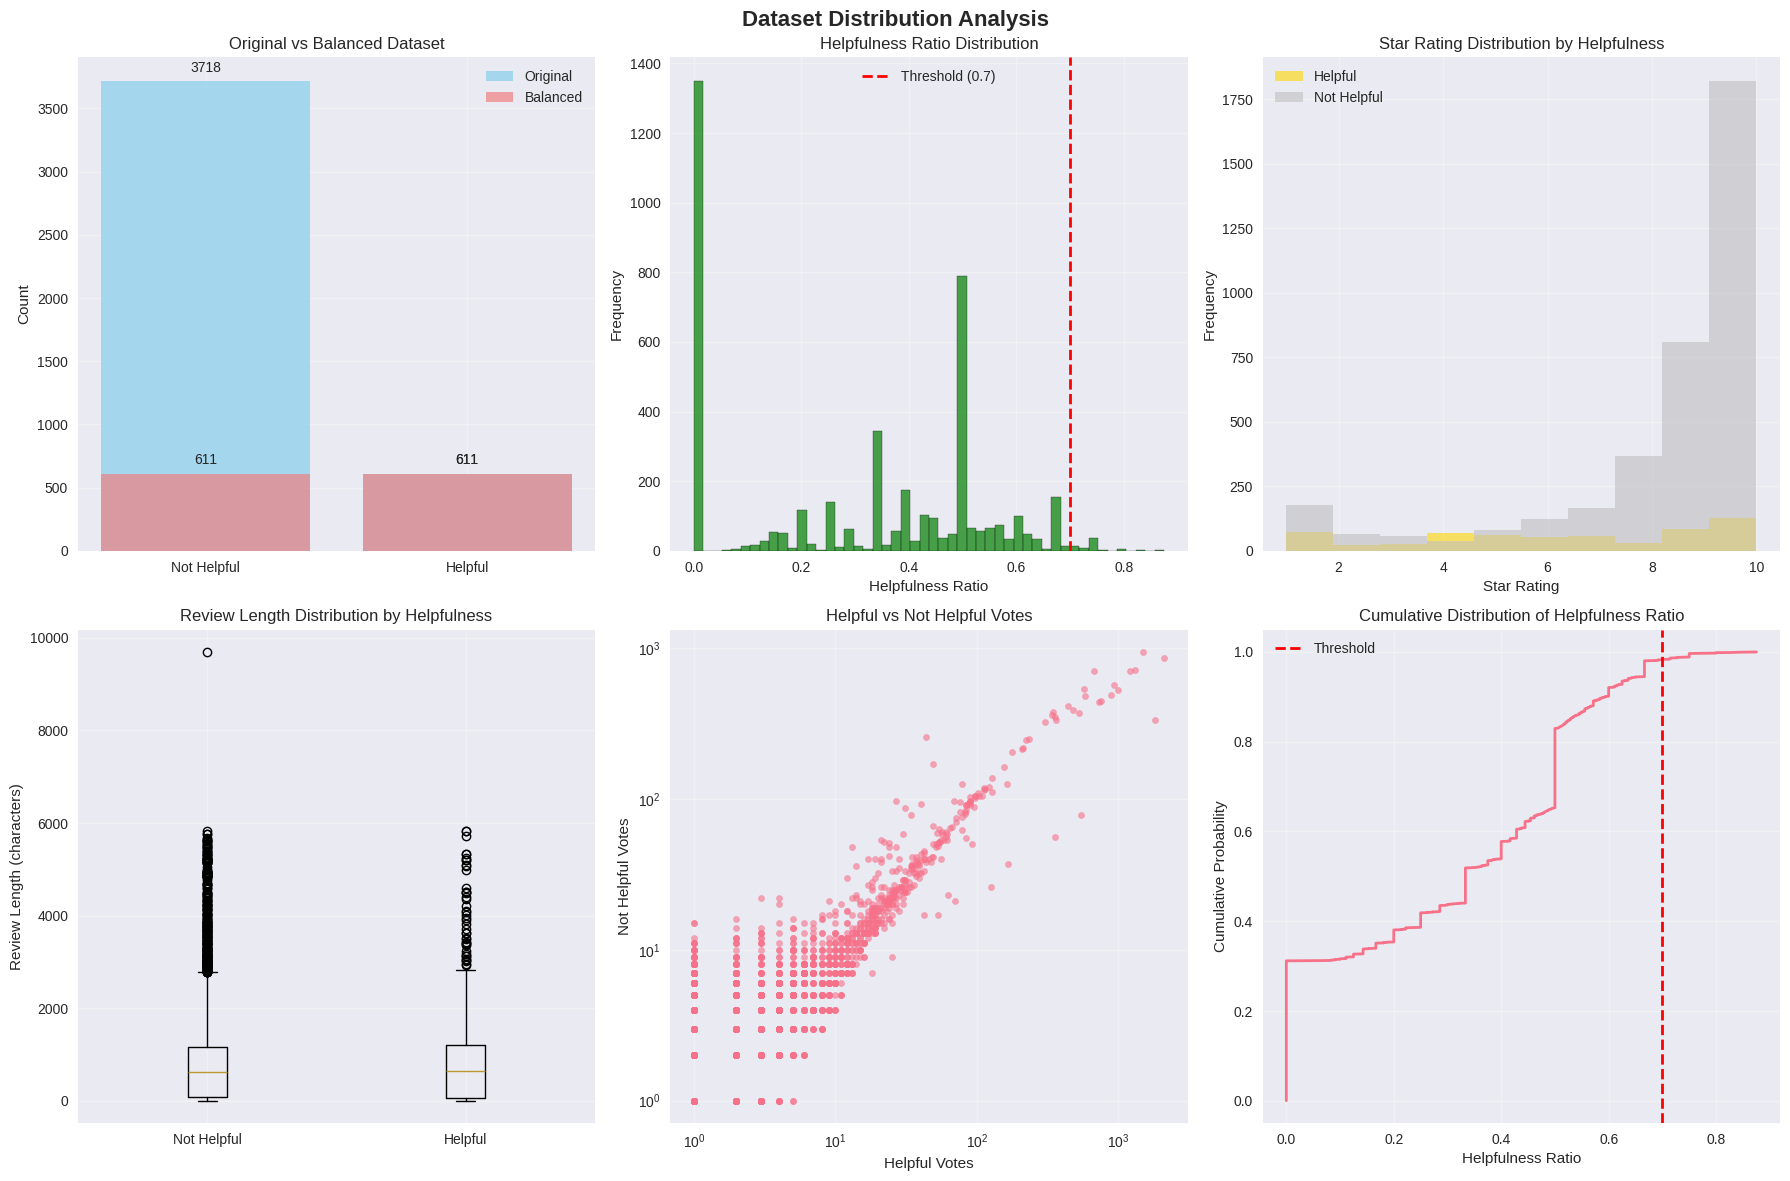

Creating Feature Analysis Visualizations...
Performing dimensionality reduction for visualization...


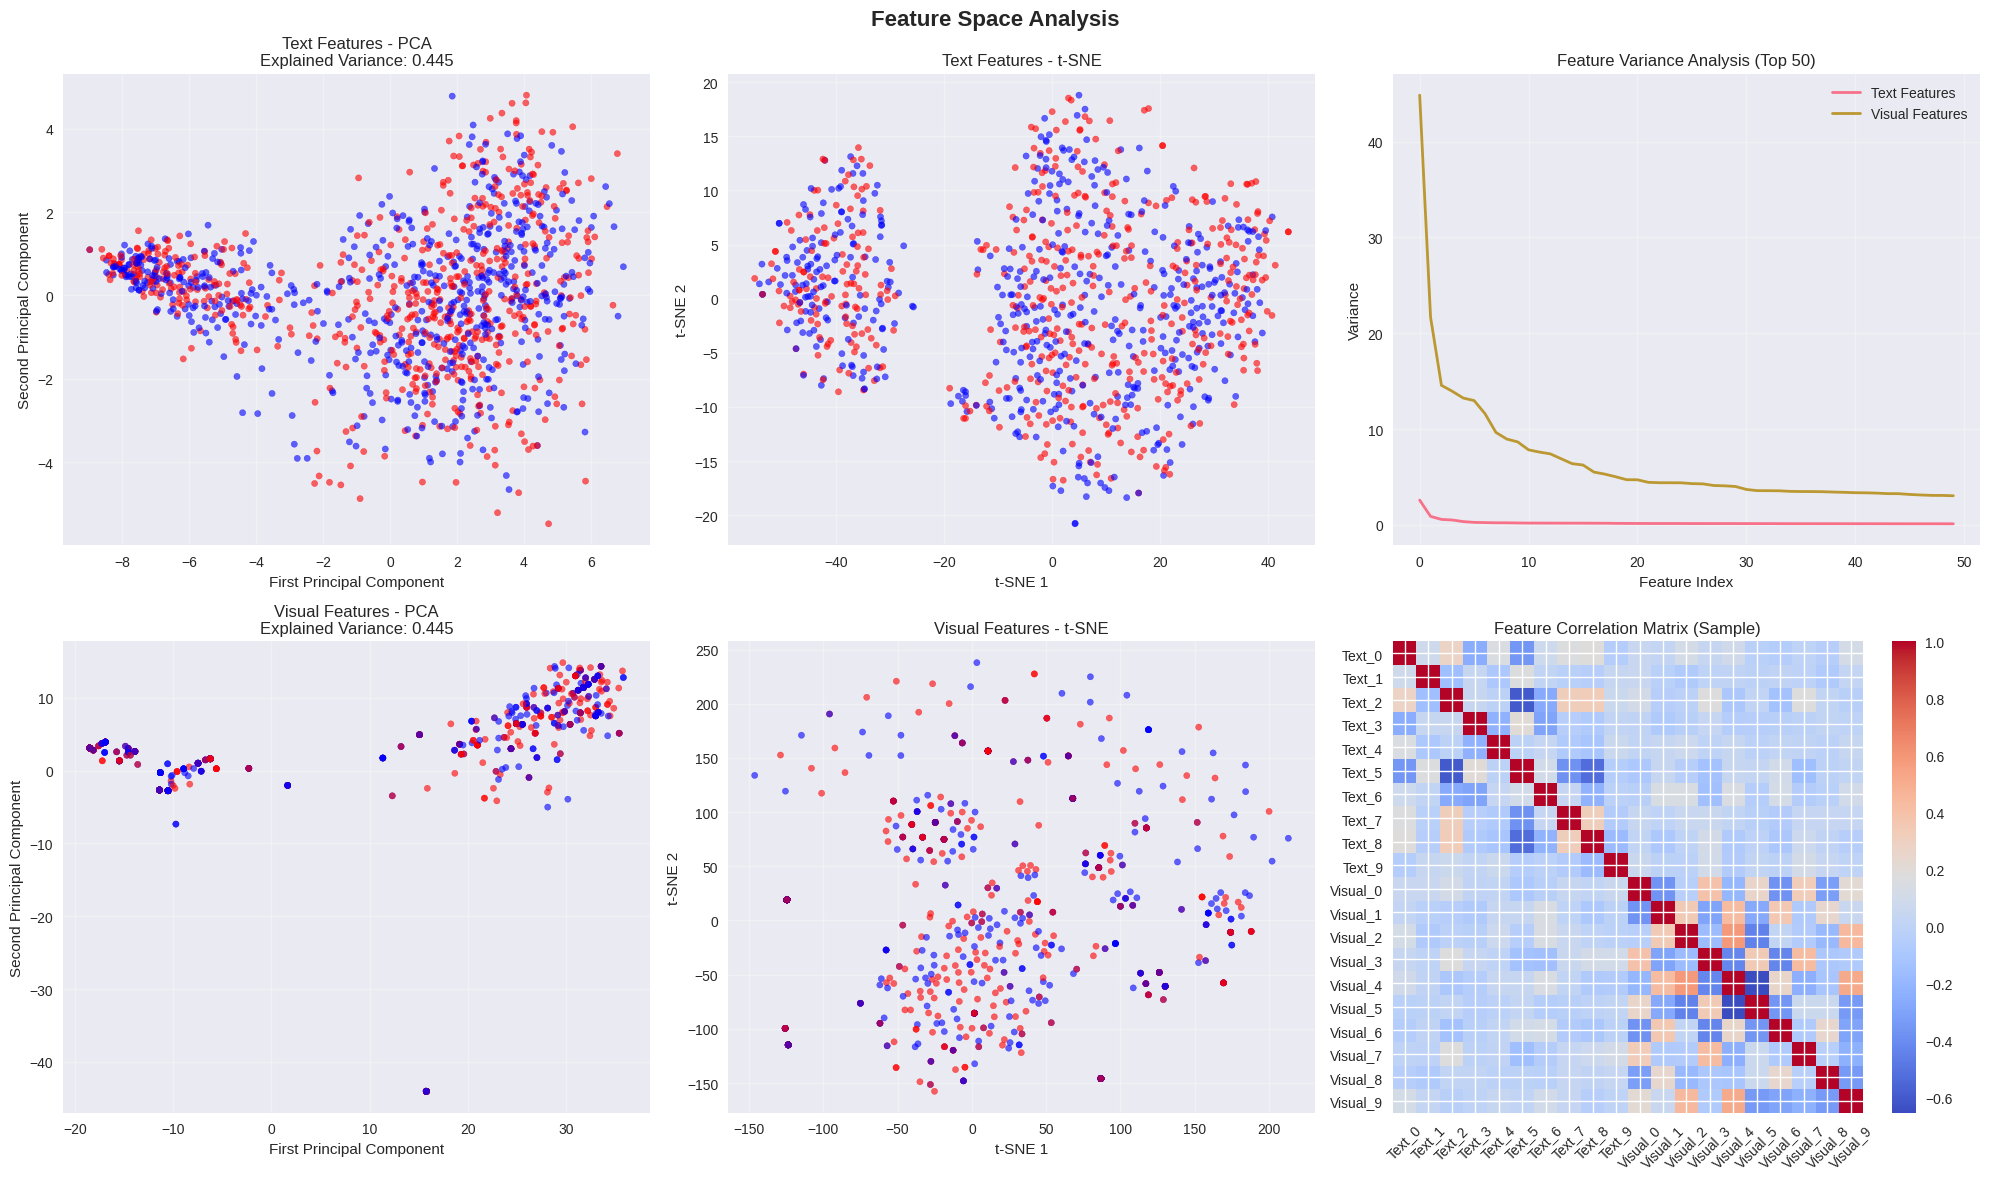

Creating Semantic Alignment Visualizations...


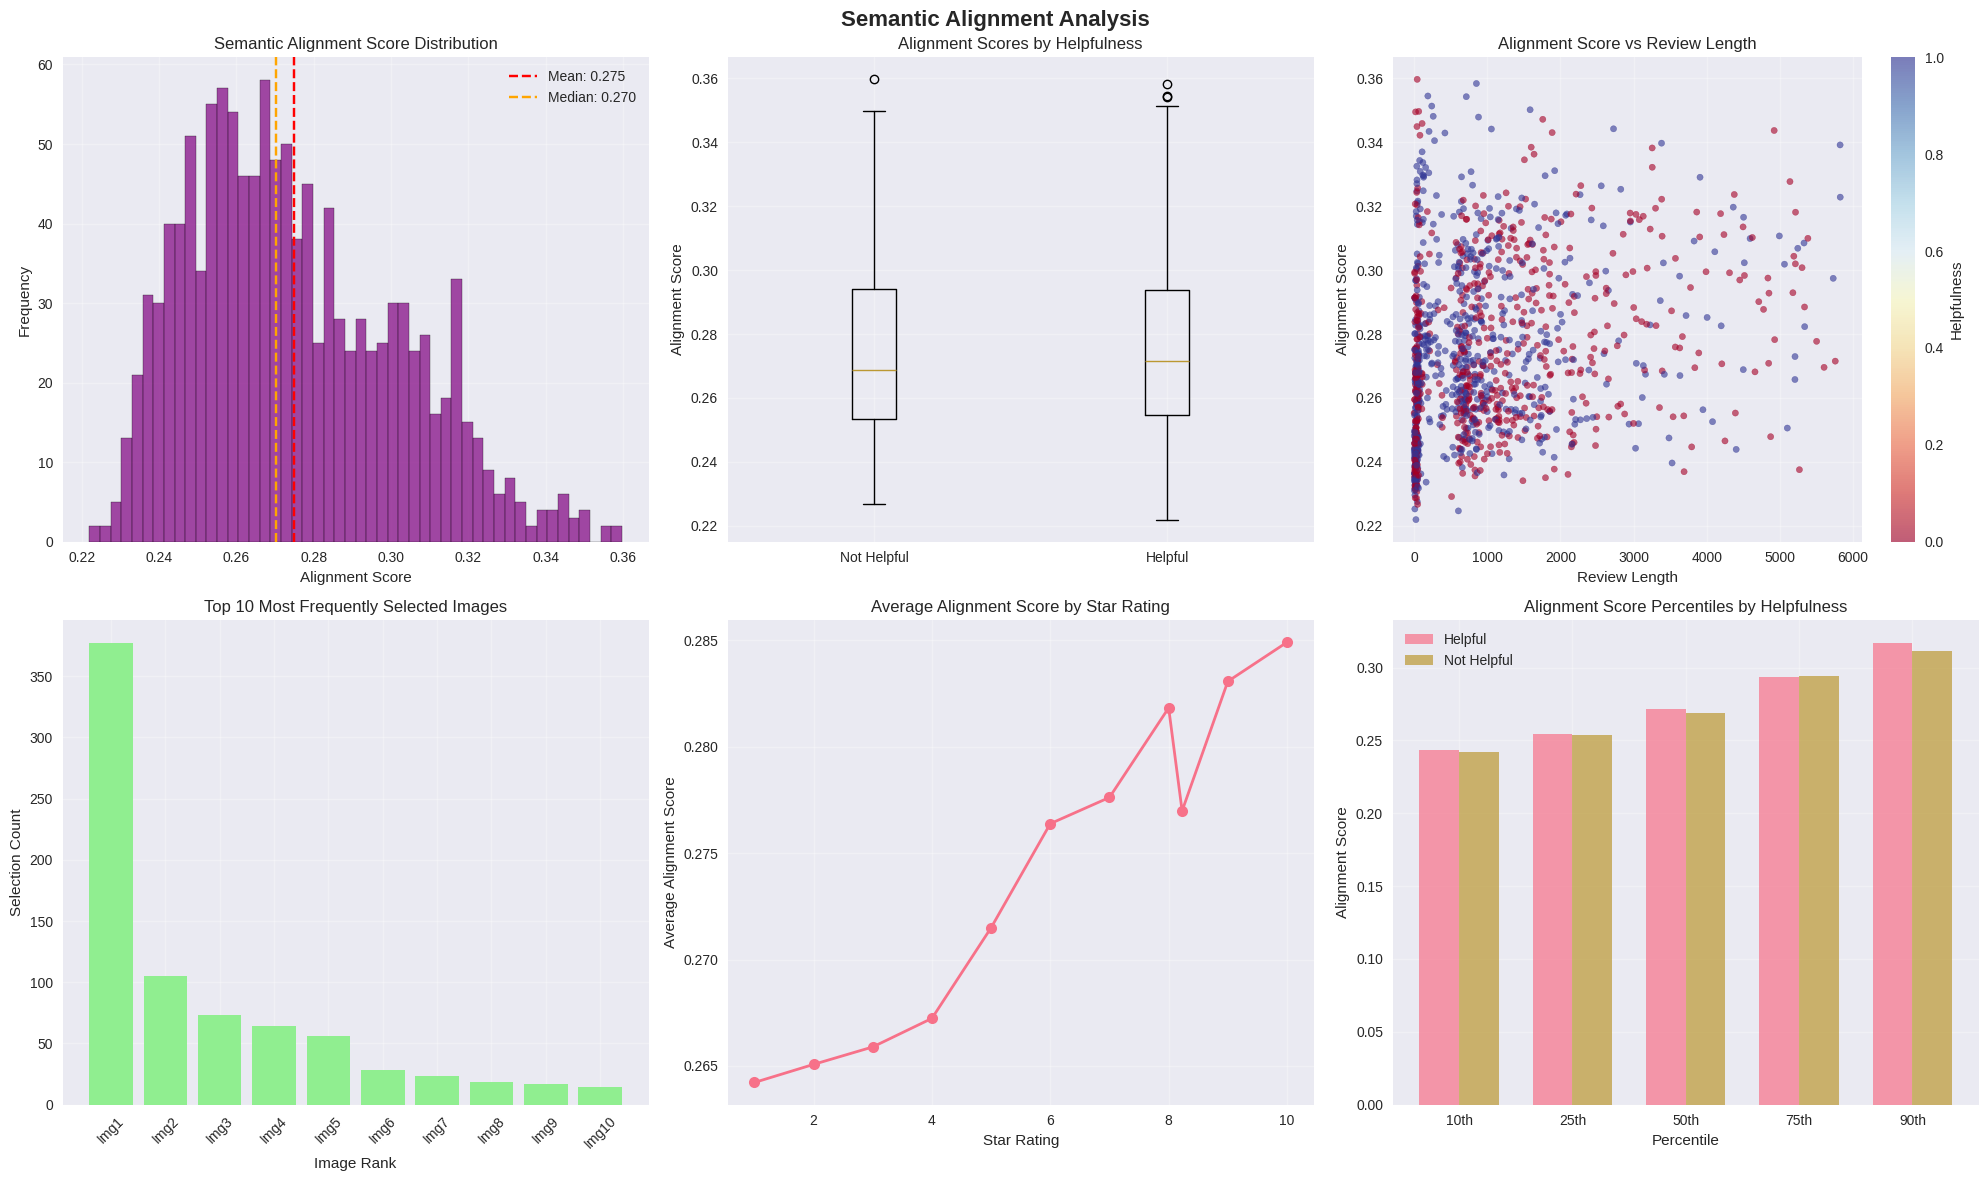

Creating Model Performance Visualizations...


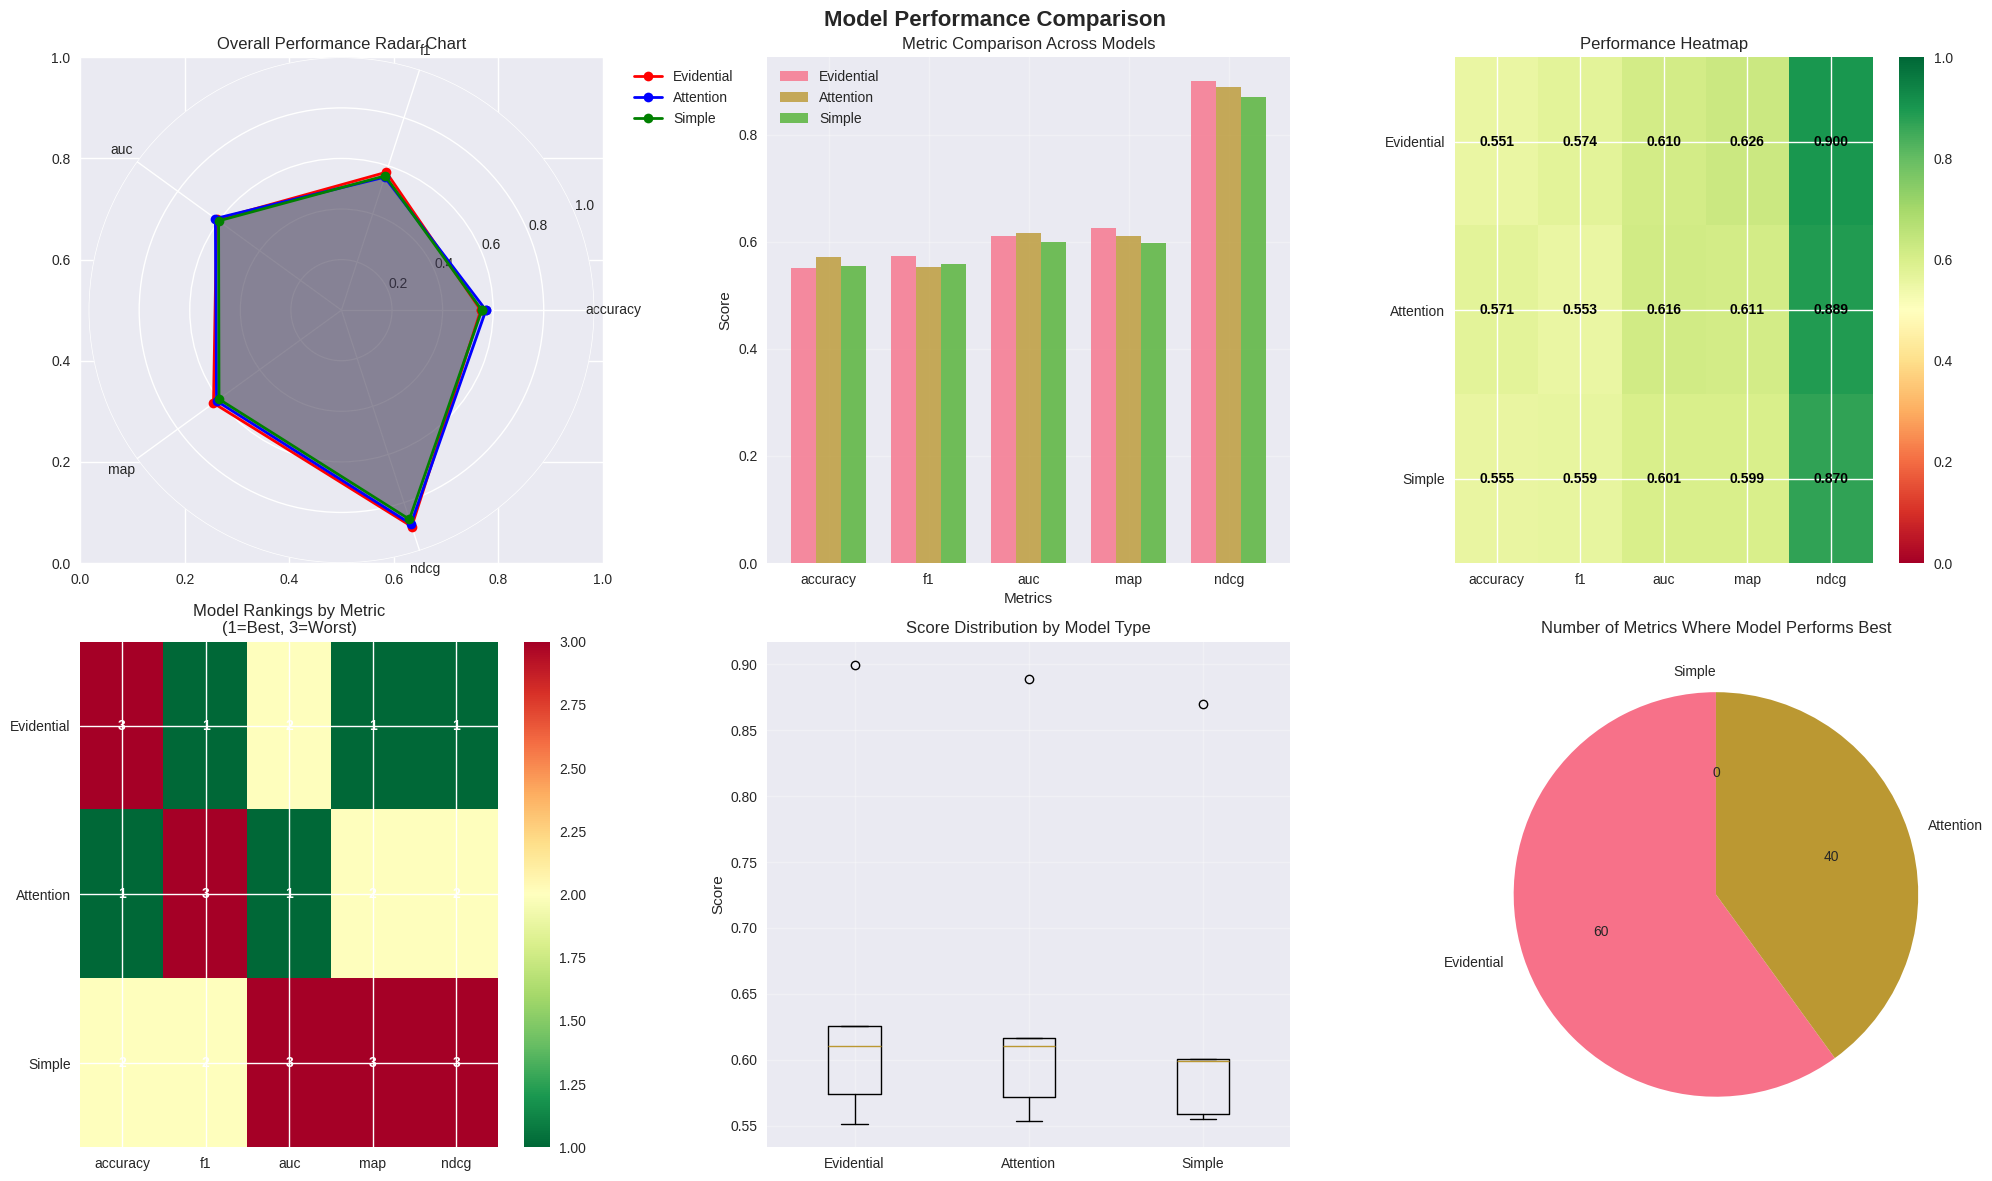

Creating Training History Visualizations...


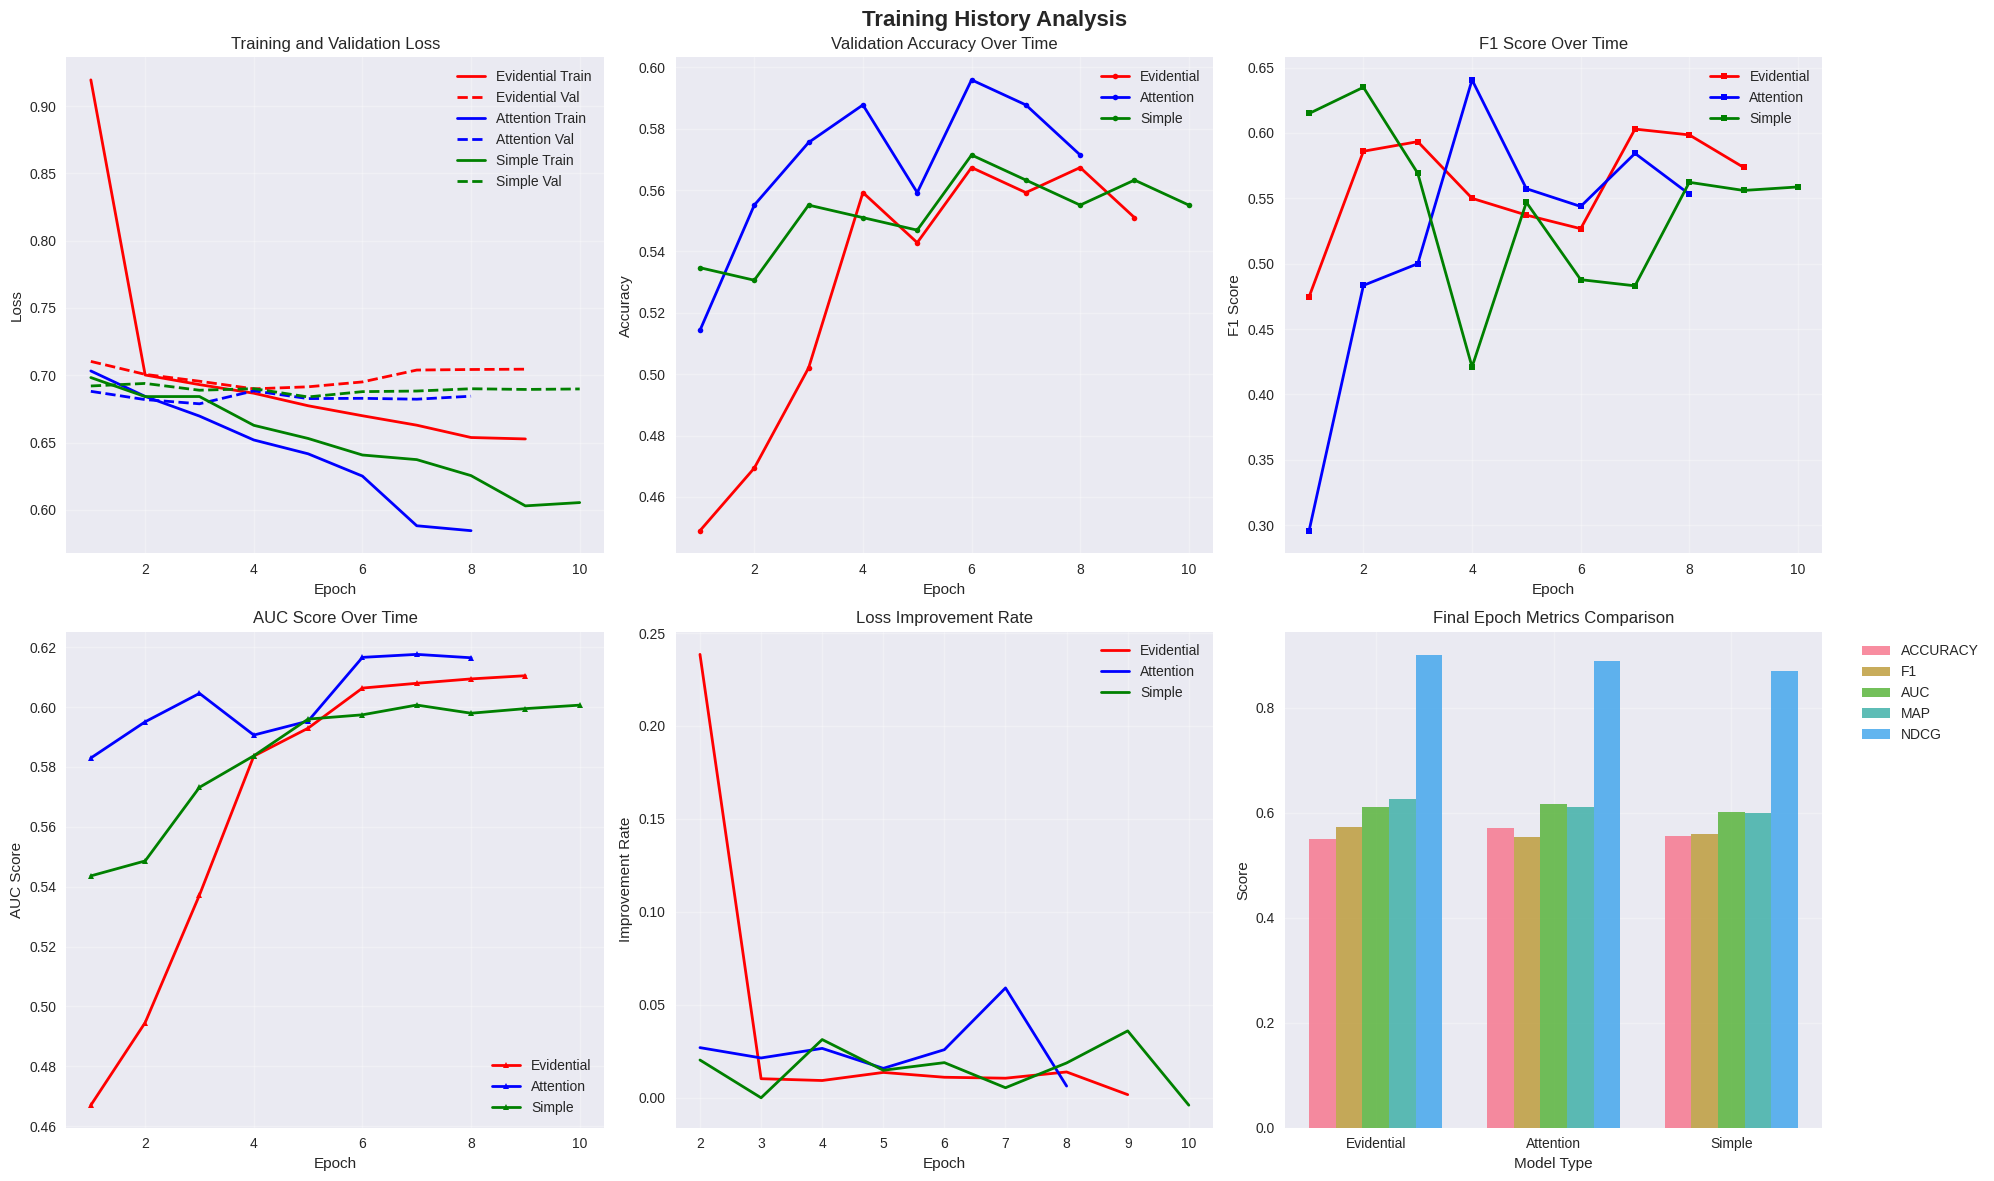

Creating Advanced Analysis Visualizations...


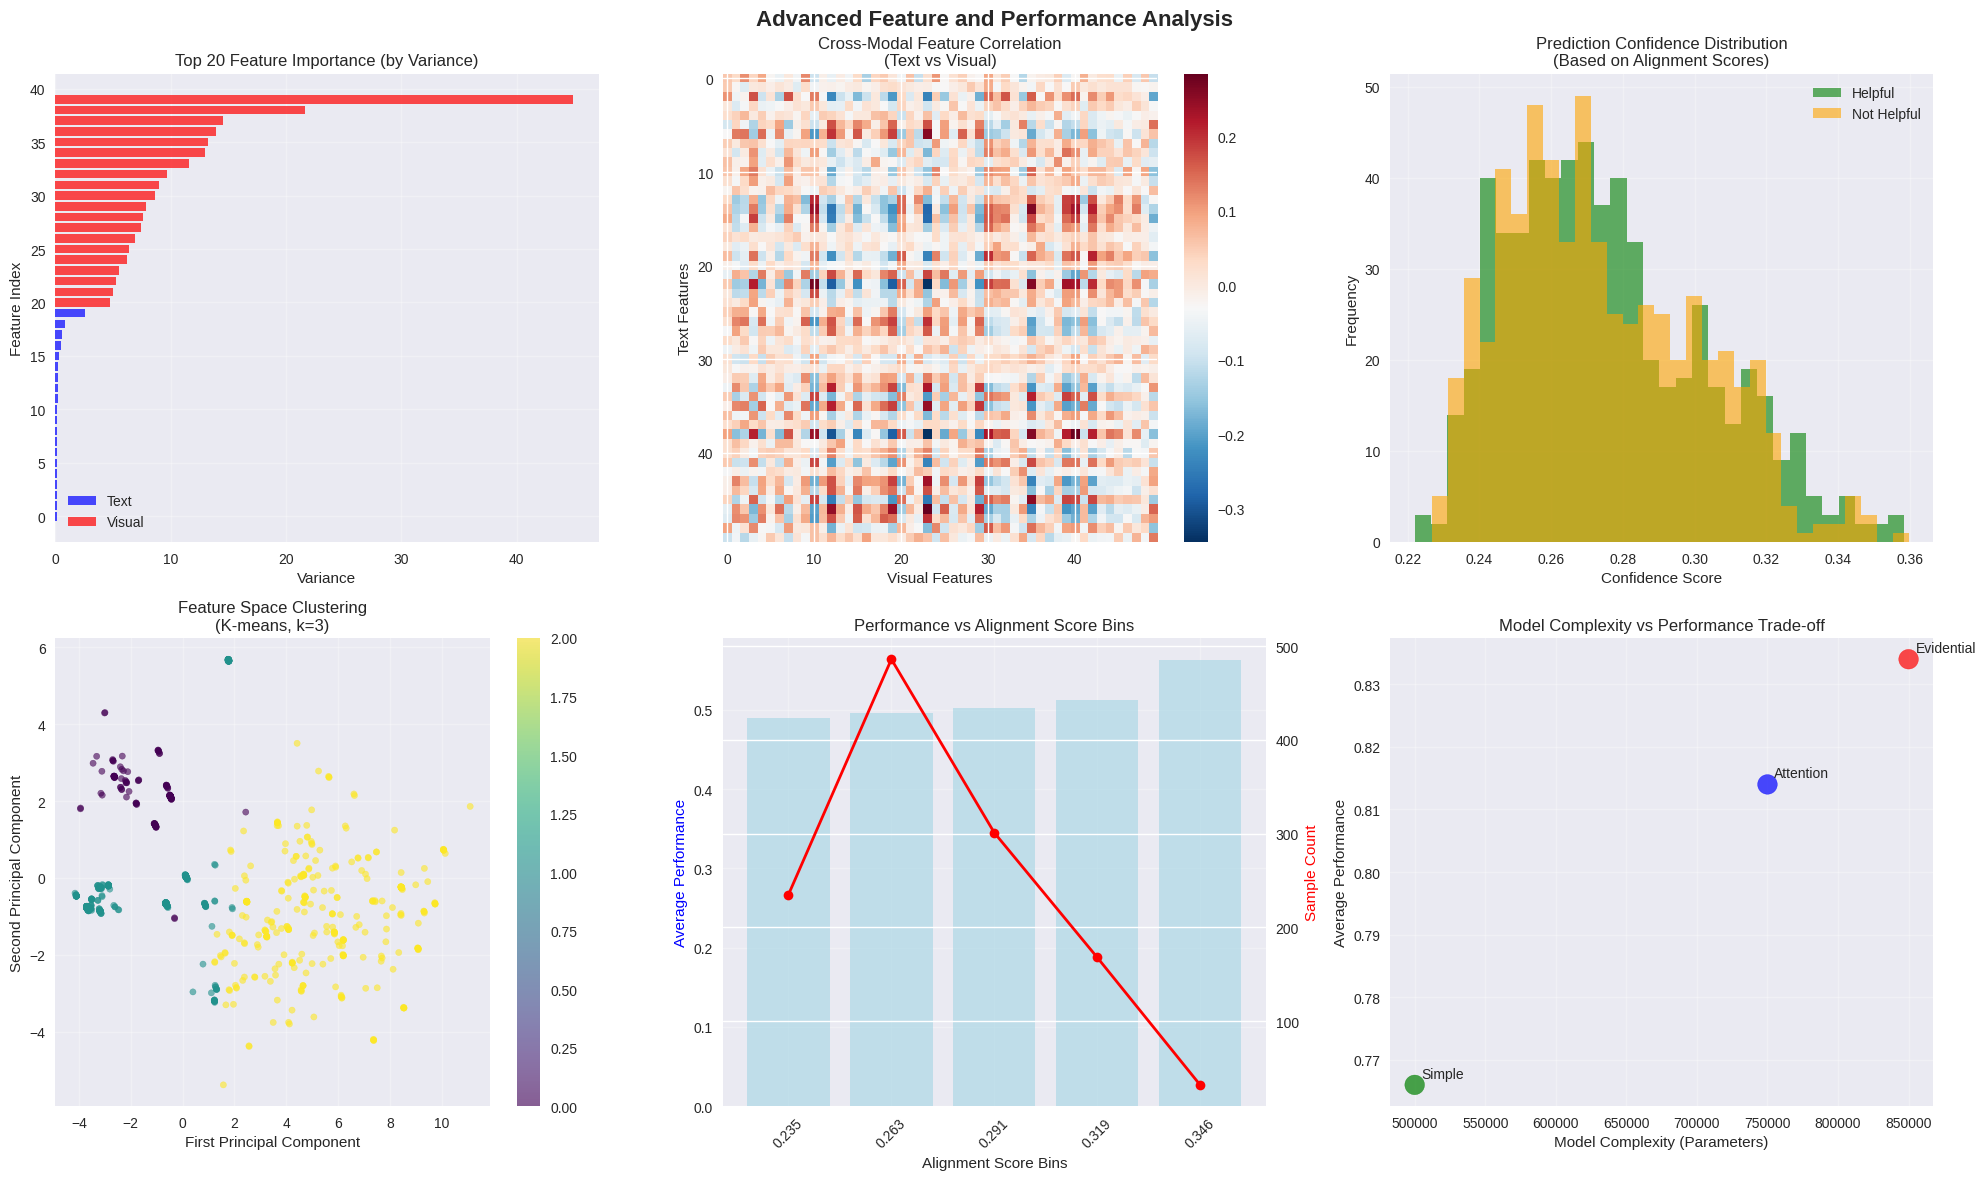

Creating Interactive Visualizations...


Visualization suite completed!


In [ ]:
run_comprehensive_visualizations()

In [ ]:
import json

def count_lines_of_code(notebook_path):
    total_loc = 0
    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook_content = json.load(f)

    for cell in notebook_content['cells']:
        if cell['cell_type'] == 'code':
            # 'source' is a list of strings, where each string is a line of code
            # We join them and then split by newline to handle cases where a single
            # source element might contain multiple lines due to how it was saved.
            code_lines = ''.join(cell['source']).splitlines()

            # Filter out empty lines and lines that are just comments
            loc = [line for line in code_lines if line.strip() and not line.strip().startswith('#')]
            total_loc += len(loc)
    return total_loc

# Replace 'your_notebook_name.ipynb' with the actual name of your downloaded notebook
notebook_file = 'Inception.ipynb'

# If you run this in Colab, you might need to upload the .ipynb file first
# or specify the full path if it's in your Google Drive.
# Example for Google Drive: from google.colab import drive; drive.mount('/content/drive')
# notebook_file = '/content/drive/MyDrive/path/to/your_notebook_name.ipynb'

lines = count_lines_of_code(notebook_file)
print(f"Total lines of code in '{notebook_file}': {lines}")

Total lines of code in 'Inception.ipynb': 1236
